# Deteccao de Fraude CNP com Otimizacao de Custo e Decisao em Cascata
**Dataset:** IEEE-CIS Fraud Detection (Vesta Corporation)

**MBA Big Data & AI — PUCRS**

| Secao | Conteudo |
|-------|---------|
| 1 | Setup e Imports |
| 2 | Carga e Merge dos Dados |
| 3 | Analise Exploratoria (EDA) |
| 4 | Feature Engineering |
| 5 | Split Temporal e Preparacao |
| 6 | Benchmark de Modelos |
| 7 | Otimizacao por Custo (Threshold Binario) |
| 8 | Analise de Sensibilidade |
| 9 | Impacto por Segmento |
| 10 | Framework de Decisao em Cascata |
| 11 | Simulacao de Volume e Projecao Financeira |
| 12 | Resumo Executivo |

## 1. Setup e Imports

In [0]:
%pip install lightgbm==3.3.5
%pip install xgboost==1.7.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.7 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 49.7 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.ensemble import IsolationForest
from scipy.stats import ks_2samp

import lightgbm as lgb
import xgboost as xgb
import time
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print("Setup completo.")

Setup completo.


## 2. Carga e Merge dos Dados

O IEEE-CIS tem dois arquivos de treino:
- `train_transaction.csv`: 590K transacoes, 394 colunas (valores, features Vesta)
- `train_identity.csv`: 145K registros, 41 colunas (device, browser)

Nem toda transacao tem identity associada. O merge e feito por `TransactionID`.

In [0]:
# Opcao A: carregar de tabelas Unity Catalog (se ja fez upload via UI)
df_trans = spark.table("workspace.ieee_cis.train_transaction").toPandas()
df_id = spark.table("workspace.ieee_cis.train_identity").toPandas()


print(f"Transacoes: {df_trans.shape[0]:,} linhas | {df_trans.shape[1]} colunas")
print(f"Identity:   {df_id.shape[0]:,} linhas | {df_id.shape[1]} colunas")
print(f"Cobertura identity: {df_id.shape[0]/df_trans.shape[0]*100:.1f}%")

Transacoes: 590,540 linhas | 394 colunas
Identity:   144,233 linhas | 41 colunas
Cobertura identity: 24.4%


In [0]:
df = df_trans.merge(df_id, on="TransactionID", how="left")

print(f"Dataset merged: {df.shape[0]:,} linhas | {df.shape[1]} colunas")
print(f"Fraudes: {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.2f}%)")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Dataset merged: 590,540 linhas | 434 colunas
Fraudes: 20,663 (3.50%)
Memoria: 2.67 GB


## 3. Analise Exploratoria (EDA)

### 3.1 Visao Geral e Missing Values

In [0]:
fraud_rate = df["isFraud"].mean() * 100
n_fraud = df["isFraud"].sum()
n_legit = (df["isFraud"] == 0).sum()

print(f"Total de transacoes:  {len(df):,}")
print(f"Legitimas:            {n_legit:,} ({100 - fraud_rate:.2f}%)")
print(f"Fraudulentas:         {n_fraud:,} ({fraud_rate:.2f}%)")
print(f"Ratio (legit:fraude): {n_legit // n_fraud}:1")

Total de transacoes:  590,540
Legitimas:            569,877 (96.50%)
Fraudulentas:         20,663 (3.50%)
Ratio (legit:fraude): 27:1


In [0]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_summary = missing_pct[missing_pct > 0]

print(f"Colunas com missing: {len(missing_summary)} de {len(df.columns)}")
print(f"\nDistribuicao de missing:")
for bucket, label in [(0, "0%"), (25, "1-25%"), (50, "25-50%"),
                       (75, "50-75%"), (100, "75-100%")]:
    if bucket == 0:
        count = (missing_pct == 0).sum()
    elif bucket == 25:
        count = ((missing_pct > 0) & (missing_pct <= 25)).sum()
    elif bucket == 50:
        count = ((missing_pct > 25) & (missing_pct <= 50)).sum()
    elif bucket == 75:
        count = ((missing_pct > 50) & (missing_pct <= 75)).sum()
    else:
        count = (missing_pct > 75).sum()
    print(f"  {label:>8s}: {count:3d} colunas")

Colunas com missing: 414 de 434

Distribuicao de missing:
        0%:  20 colunas
     1-25%: 162 colunas
    25-50%:  38 colunas
    50-75%:   6 colunas
   75-100%: 208 colunas


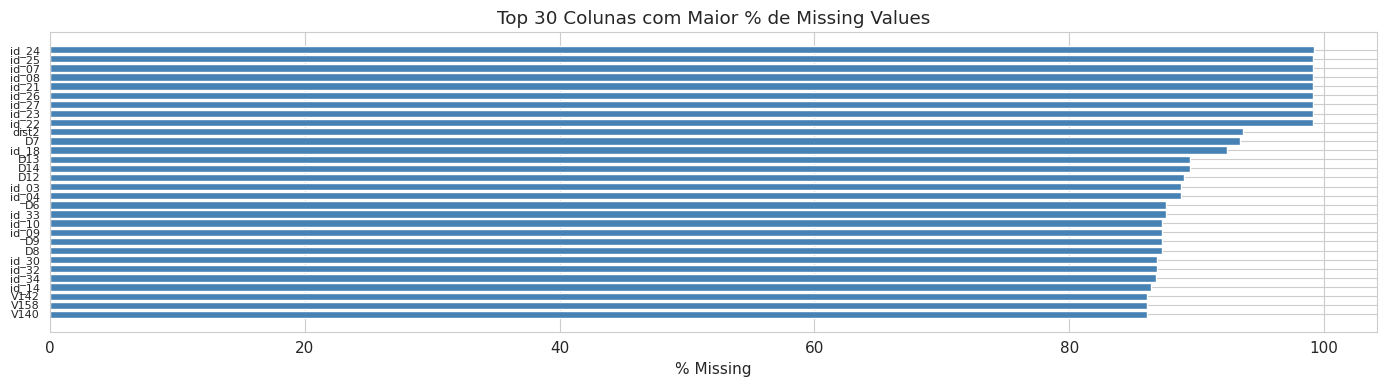

In [0]:
fig, ax = plt.subplots(figsize=(14, 4))
top_missing = missing_summary.head(30)
ax.barh(range(len(top_missing)), top_missing.values, color="steelblue")
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing.index, fontsize=8)
ax.set_xlabel("% Missing")
ax.set_title("Top 30 Colunas com Maior % de Missing Values")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3.2 Analise Temporal

`TransactionDT` e um timedelta em segundos a partir de uma data de referencia.
Nao sabemos a data exata, mas sabemos que cobre ~6 meses.

In [0]:
df["TransactionDay"] = df["TransactionDT"] / 86400
df["TransactionWeek"] = (df["TransactionDay"] / 7).astype(int)

total_days = df["TransactionDay"].max() - df["TransactionDay"].min()
print(f"Span temporal: {total_days:.0f} dias ({total_days/30:.1f} meses)")
print(f"Dia min: {df['TransactionDay'].min():.1f} | Dia max: {df['TransactionDay'].max():.1f}")

Span temporal: 182 dias (6.1 meses)
Dia min: 1.0 | Dia max: 183.0


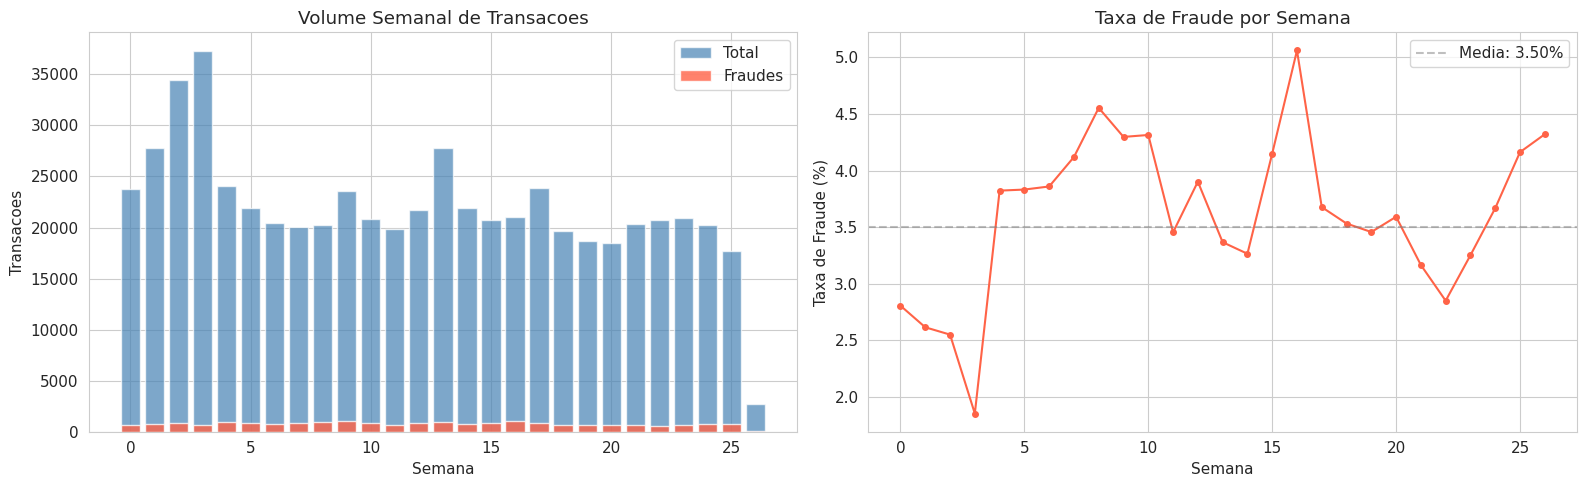

In [0]:
weekly = df.groupby("TransactionWeek").agg(
    total=("isFraud", "count"),
    frauds=("isFraud", "sum")
).reset_index()
weekly["fraud_rate"] = weekly["frauds"] / weekly["total"] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(weekly["TransactionWeek"], weekly["total"],
            color="steelblue", alpha=0.7, label="Total")
axes[0].bar(weekly["TransactionWeek"], weekly["frauds"],
            color="tomato", alpha=0.8, label="Fraudes")
axes[0].set_xlabel("Semana")
axes[0].set_ylabel("Transacoes")
axes[0].set_title("Volume Semanal de Transacoes")
axes[0].legend()

axes[1].plot(weekly["TransactionWeek"], weekly["fraud_rate"],
             color="tomato", marker="o", markersize=4)
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("Taxa de Fraude (%)")
axes[1].set_title("Taxa de Fraude por Semana")
axes[1].axhline(y=fraud_rate, color="gray", linestyle="--",
                alpha=0.5, label=f"Media: {fraud_rate:.2f}%")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.3 Distribuicao de Valores

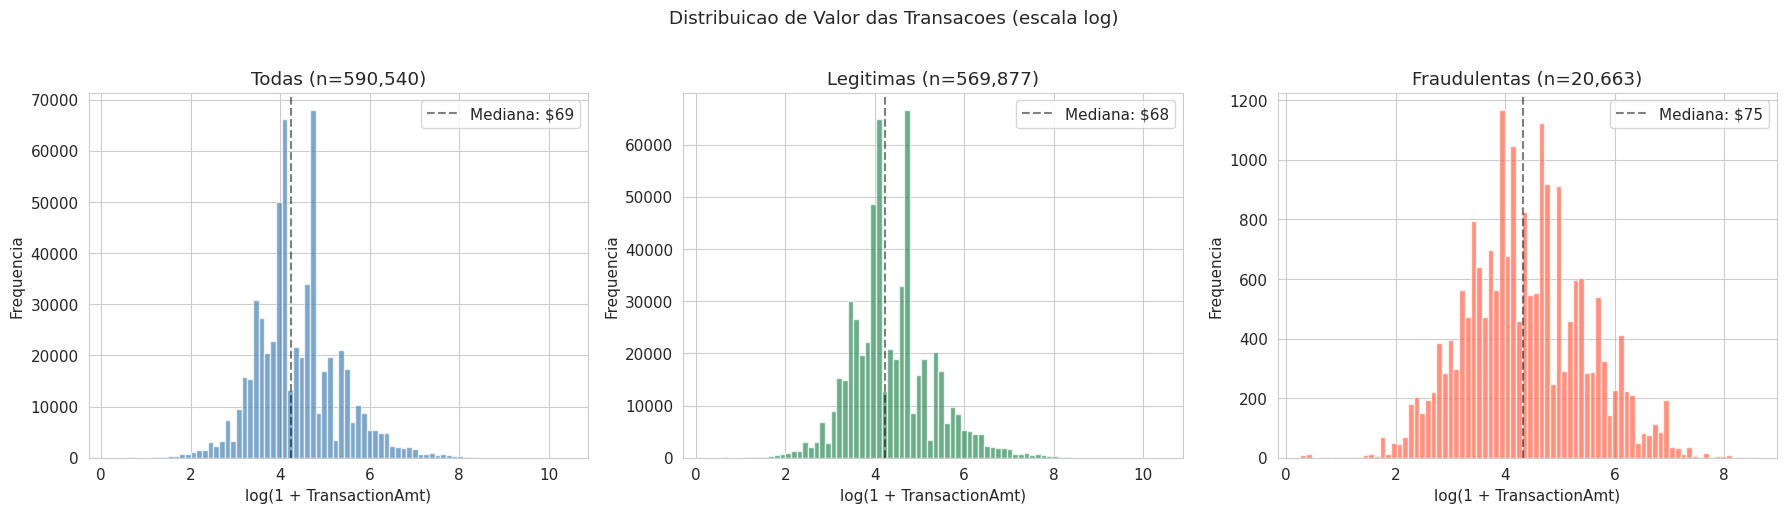

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, subset, title, color in [
    (axes[0], df, "Todas", "steelblue"),
    (axes[1], df[df["isFraud"] == 0], "Legitimas", "seagreen"),
    (axes[2], df[df["isFraud"] == 1], "Fraudulentas", "tomato"),
]:
    vals = np.log1p(subset["TransactionAmt"])
    ax.hist(vals, bins=80, color=color, alpha=0.7, edgecolor="white")
    ax.set_xlabel("log(1 + TransactionAmt)")
    ax.set_ylabel("Frequencia")
    ax.set_title(f"{title} (n={len(subset):,})")
    ax.axvline(vals.median(), color="black", linestyle="--",
               alpha=0.5, label=f"Mediana: ${np.expm1(vals.median()):.0f}")
    ax.legend()

plt.suptitle("Distribuicao de Valor das Transacoes (escala log)", y=1.02)
plt.tight_layout()
plt.show()

In [0]:
amt_stats = df.groupby("isFraud")["TransactionAmt"].describe()
print("Estatisticas de TransactionAmt por classe:")
print(amt_stats.to_string())

Estatisticas de TransactionAmt por classe:
              count     mean      std    min     25%     50%      75%        max
isFraud                                                                         
0       569877.0000 134.5117 239.3951 0.2510 43.9700 68.5000 120.0000 31937.3910
1        20663.0000 149.2448 232.2122 0.2920 35.0440 75.0000 161.0000  5191.0000


### 3.4 Features Categoricas Principais

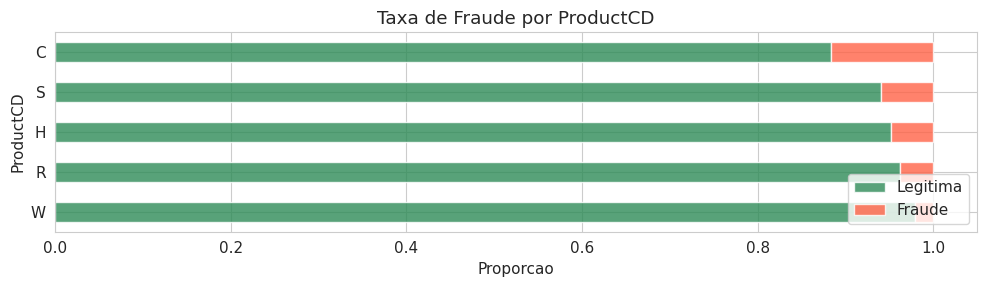

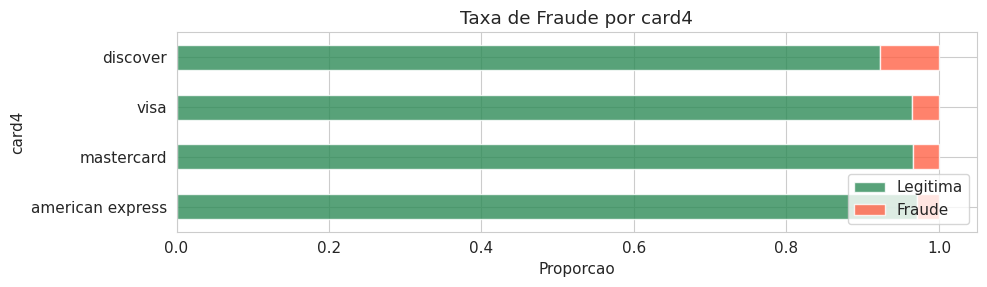

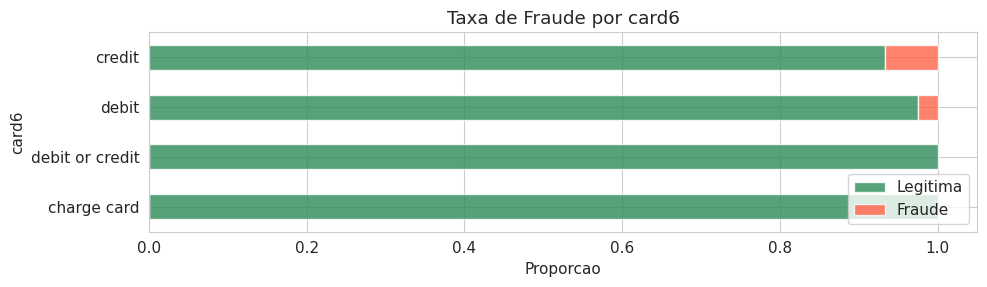

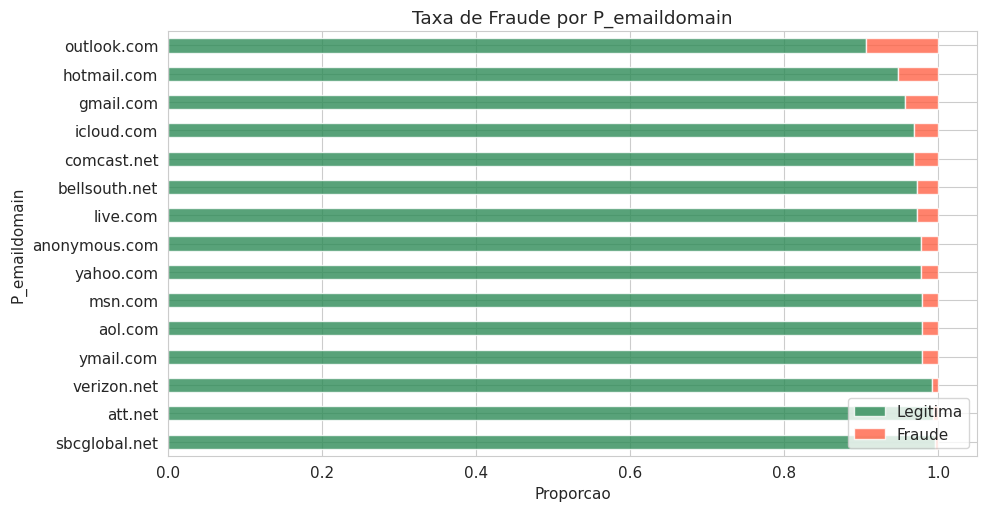

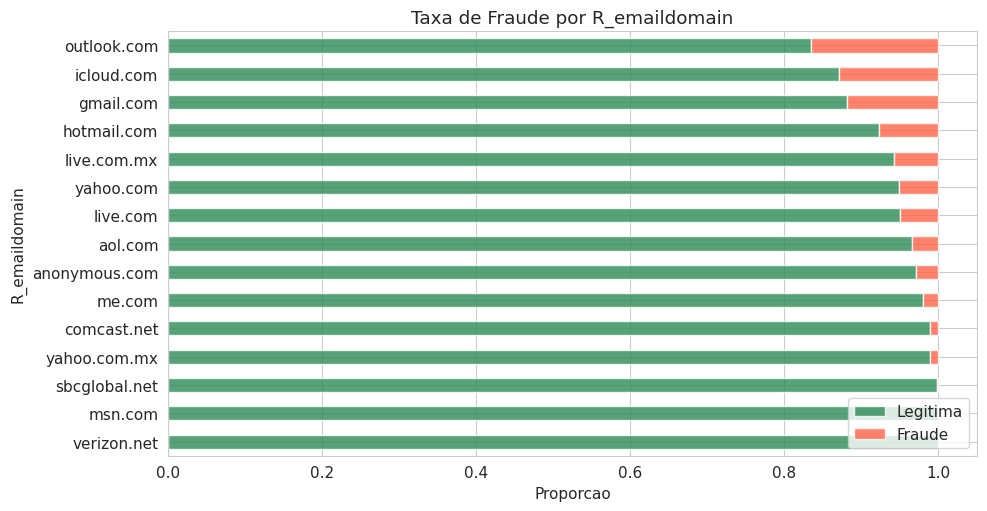

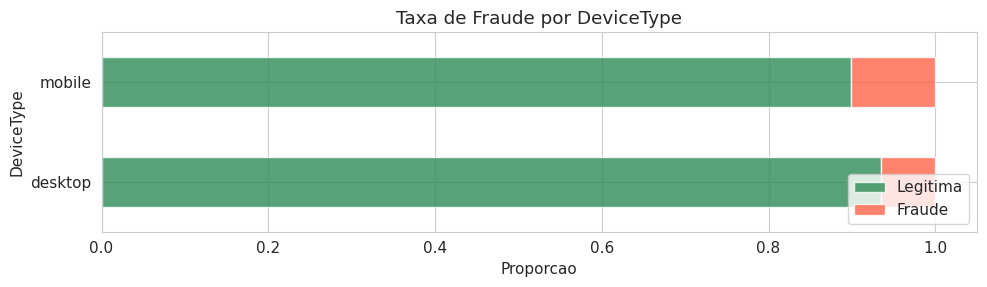

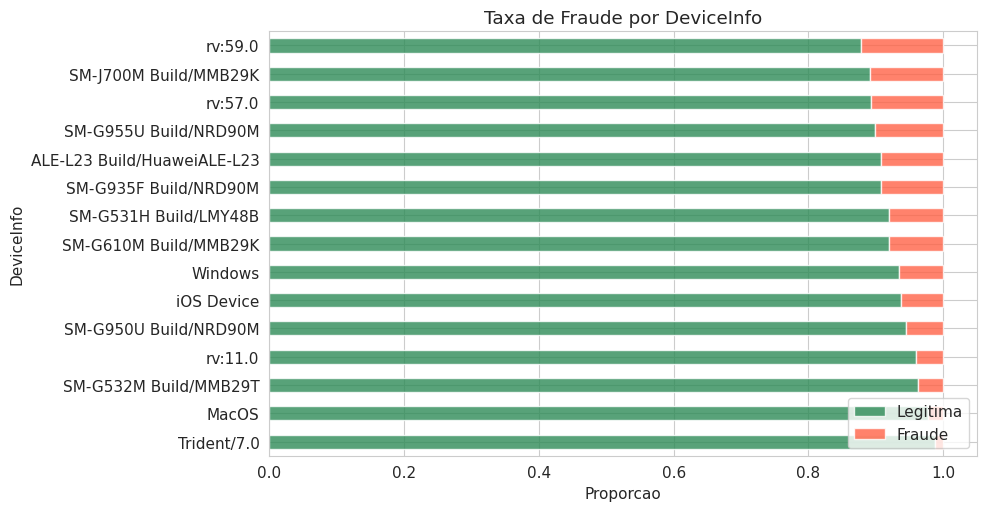

In [0]:
cat_features = ["ProductCD", "card4", "card6", "P_emaildomain",
                "R_emaildomain", "DeviceType", "DeviceInfo"]

for feat in cat_features:
    if feat not in df.columns:
        continue
    ct = pd.crosstab(df[feat], df["isFraud"], normalize="index")
    if len(ct) > 15:
        top_vals = df[feat].value_counts().head(15).index
        ct = ct.loc[ct.index.isin(top_vals)]
    ct = ct.sort_values(1, ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(3, len(ct) * 0.35)))
    ct.plot(kind="barh", stacked=True, ax=ax,
            color=["seagreen", "tomato"], alpha=0.8)
    ax.set_xlabel("Proporcao")
    ax.set_title(f"Taxa de Fraude por {feat}")
    ax.legend(["Legitima", "Fraude"], loc="lower right")
    plt.tight_layout()
    plt.show()

### 3.5 Correlacao das Features V com Fraude

In [0]:
v_cols = [c for c in df.columns if c.startswith("V")]
print(f"Features V (Vesta): {len(v_cols)}")

v_corr = df[v_cols + ["isFraud"]].corr()["isFraud"].drop("isFraud")
v_corr_sorted = v_corr.abs().sort_values(ascending=False)

print(f"\nTop 20 features V mais correlacionadas com fraude:")
for feat, corr in v_corr_sorted.head(20).items():
    direction = "+" if v_corr[feat] > 0 else "-"
    print(f"  {feat:>6s}: {direction}{corr:.4f}")

Features V (Vesta): 339

Top 20 features V mais correlacionadas com fraude:
    V257: +0.3831
    V246: +0.3669
    V244: +0.3641
    V242: +0.3606
    V201: +0.3280
    V200: +0.3188
    V189: +0.3082
    V188: +0.3036
    V258: +0.2972
     V45: +0.2818
    V158: +0.2781
    V156: +0.2760
    V149: +0.2733
    V228: +0.2689
     V44: +0.2604
     V86: +0.2518
     V87: +0.2517
    V170: +0.2498
    V147: +0.2429
     V52: +0.2395


## 4. Feature Engineering

Estrategia:
1. Remover colunas com >70% missing
2. Selecionar features V com maior correlacao com fraude
3. Criar features temporais e de interacao
4. Encodar categoricas

### 4.1 Remocao de Colunas com Alto Missing

In [0]:
MISSING_THRESHOLD = 0.70

missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > MISSING_THRESHOLD].index.tolist()
cols_to_drop = [c for c in cols_to_drop if c != "isFraud"]

print(f"Colunas removidas (>{MISSING_THRESHOLD*100:.0f}% missing): {len(cols_to_drop)}")

df_clean = df.drop(columns=cols_to_drop)
print(f"Dataset apos limpeza: {df_clean.shape[1]} colunas (de {df.shape[1]})")

Colunas removidas (>70% missing): 208
Dataset apos limpeza: 228 colunas (de 436)


### 4.2 Selecao de Features V

In [0]:
N_TOP_V = 40

v_remaining = [c for c in v_cols if c in df_clean.columns]
v_corr_remaining = df_clean[v_remaining + ["isFraud"]].corr()["isFraud"].drop("isFraud")
top_v = v_corr_remaining.abs().sort_values(ascending=False).head(N_TOP_V).index.tolist()

v_to_drop = [c for c in v_remaining if c not in top_v]
df_clean = df_clean.drop(columns=v_to_drop)

print(f"Features V mantidas: {len(top_v)} de {len(v_remaining)}")
print(f"Dataset apos selecao V: {df_clean.shape[1]} colunas")

Features V mantidas: 40 de 180
Dataset apos selecao V: 88 colunas


### 4.3 Features Temporais e de Interacao

In [0]:
df_clean["TransactionHour"] = (
    (df_clean["TransactionDT"] / 3600) % 24
).astype(int)

df_clean["hour_sin"] = np.sin(2 * np.pi * df_clean["TransactionHour"] / 24)
df_clean["hour_cos"] = np.cos(2 * np.pi * df_clean["TransactionHour"] / 24)

df_clean["TransactionDayOfWeek"] = (
    (df_clean["TransactionDay"]) % 7
).astype(int)

df_clean["amt_log"] = np.log1p(df_clean["TransactionAmt"])

if "card1" in df_clean.columns:
    card1_stats = df_clean.groupby("card1")["TransactionAmt"].agg(
        ["mean", "std", "count"]
    ).rename(columns={"mean": "card1_amt_mean",
                       "std": "card1_amt_std",
                       "count": "card1_freq"})
    df_clean = df_clean.merge(card1_stats, on="card1", how="left")
    df_clean["card1_amt_deviation"] = (
        (df_clean["TransactionAmt"] - df_clean["card1_amt_mean"])
        / df_clean["card1_amt_std"].clip(lower=1)
    )

if "addr1" in df_clean.columns and "P_emaildomain" in df_clean.columns:
    df_clean["addr_email_match"] = (
        df_clean["addr1"].astype(str) + "_" + df_clean["P_emaildomain"].astype(str)
    )

new_feats = [
    "TransactionHour", "hour_sin", "hour_cos",
    "TransactionDayOfWeek", "amt_log",
    "card1_amt_mean", "card1_amt_std", "card1_freq", "card1_amt_deviation"
]
new_feats = [f for f in new_feats if f in df_clean.columns]
print(f"Features criadas: {len(new_feats)}")
for f in new_feats:
    print(f"  {f}: {df_clean[f].dtype}")

Features criadas: 9
  TransactionHour: int64
  hour_sin: float64
  hour_cos: float64
  TransactionDayOfWeek: int64
  amt_log: float64
  card1_amt_mean: float64
  card1_amt_std: float64
  card1_freq: int64
  card1_amt_deviation: float64


### 4.4 Encoding de Categoricas

In [0]:
EXCLUDE_COLS = ["TransactionID", "isFraud", "TransactionDT",
                "TransactionDay", "TransactionWeek"]

cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
cat_cols = [c for c in cat_cols if c not in EXCLUDE_COLS]

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = df_clean[col].fillna("__MISSING__")
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

print(f"Categoricas encodadas: {len(cat_cols)}")

Categoricas encodadas: 14


### 4.5 Dataset Final

In [0]:
feature_cols = [c for c in df_clean.columns if c not in EXCLUDE_COLS]

remaining_missing = df_clean[feature_cols].isnull().mean()
cols_still_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
if len(cols_still_missing) > 0:
    print(f"Colunas com missing restante: {len(cols_still_missing)}")
    print("Preenchendo com mediana (numericas)...")
    for col in cols_still_missing.index:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

feature_cols = [c for c in df_clean.columns if c not in EXCLUDE_COLS]
print(f"\nDataset final para modelagem:")
print(f"  Linhas:   {len(df_clean):,}")
print(f"  Features: {len(feature_cols)}")
print(f"  Target:   isFraud (fraude={df_clean['isFraud'].sum():,})")

Colunas com missing restante: 56
Preenchendo com mediana (numericas)...

Dataset final para modelagem:
  Linhas:   590,540
  Features: 93
  Target:   isFraud (fraude=20,663)


## 5. Split Temporal e Preparacao

Simulando producao real: treino nos primeiros ~4 meses, teste nos ultimos ~2 meses.
Isso evita data leakage e permite medir drift temporal.

In [0]:
day_quantiles = df_clean["TransactionDay"].quantile([0.25, 0.50, 0.65, 0.75])
print("Quantis temporais (dias):")
print(day_quantiles.to_string())

TRAIN_CUTOFF = df_clean["TransactionDay"].quantile(0.65)
print(f"\nCutoff treino/teste: dia {TRAIN_CUTOFF:.1f}")

train_mask = df_clean["TransactionDay"] <= TRAIN_CUTOFF
test_mask = df_clean["TransactionDay"] > TRAIN_CUTOFF

X_train = df_clean.loc[train_mask, feature_cols].copy()
y_train = df_clean.loc[train_mask, "isFraud"].copy()
X_test = df_clean.loc[test_mask, feature_cols].copy()
y_test = df_clean.loc[test_mask, "isFraud"].copy()

test_amounts = df_clean.loc[test_mask, "TransactionAmt"].copy()
test_days = df_clean.loc[test_mask, "TransactionDay"].copy()

print(f"\nTreino: {len(X_train):,} ({y_train.mean()*100:.2f}% fraude)")
print(f"Teste:  {len(X_test):,} ({y_test.mean()*100:.2f}% fraude)")
print(f"Features: {len(feature_cols)}")

Quantis temporais (dias):
0.2500    35.0354
0.5000    84.5663
0.6500   111.2809
0.7500   130.1692

Cutoff treino/teste: dia 111.3

Treino: 383,851 (3.42% fraude)
Teste:  206,689 (3.65% fraude)
Features: 93


### 5.1 Isolation Forest (Anomaly Score)

In [0]:
NUMERIC_FEATURES = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Treinando Isolation Forest com {len(NUMERIC_FEATURES)} features numericas...")
t0 = time.time()

iforest = IsolationForest(
    n_estimators=200,
    max_samples=0.5,
    contamination=0.035,
    random_state=42,
    n_jobs=-1
)
iforest.fit(X_train[NUMERIC_FEATURES])

X_train["anomaly_score"] = -iforest.decision_function(X_train[NUMERIC_FEATURES])
X_test["anomaly_score"] = -iforest.decision_function(X_test[NUMERIC_FEATURES])

elapsed = time.time() - t0
print(f"Isolation Forest treinado em {elapsed:.1f}s")
print(f"anomaly_score — treino: [{X_train['anomaly_score'].min():.3f}, "
      f"{X_train['anomaly_score'].max():.3f}]")

if "anomaly_score" not in feature_cols:
    feature_cols.append("anomaly_score")

Treinando Isolation Forest com 93 features numericas...
Isolation Forest treinado em 23.8s
anomaly_score — treino: [-0.086, 0.265]


## 6. Benchmark de Modelos

In [0]:
def find_optimal_threshold(y_true, y_proba, metric="f1", n_thresholds=100):
    thresholds = np.linspace(0.1, 0.95, n_thresholds)
    best_score = -1
    best_t = 0.5
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        if y_pred.sum() == 0:
            continue
        if metric == "f1":
            score = f1_score(y_true, y_pred)
        elif metric == "recall":
            score = recall_score(y_true, y_pred)
        if score > best_score:
            best_score = score
            best_t = t
    return best_t, best_score


def evaluate_model(model, X, y, threshold=0.5):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    results = {
        "recall": recall_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred),
        "auc_roc": roc_auc_score(y, y_proba),
        "auc_pr": average_precision_score(y, y_proba),
    }
    return results, y_proba

In [0]:
features_no_anomaly = [f for f in feature_cols if f != "anomaly_score"]
features_with_anomaly = feature_cols.copy()

MODEL_CONFIGS = {
    "LightGBM": {
        "features": features_no_anomaly,
        "model_class": lgb.LGBMClassifier,
        "params": {
            "n_estimators": 500,
            "max_depth": 7,
            "learning_rate": 0.05,
            "num_leaves": 63,
            "min_child_samples": 50,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "scale_pos_weight": 1,
            "random_state": 42,
            "verbose": -1,
            "n_jobs": -1,
        },
    },
    "LightGBM + iForest": {
        "features": features_with_anomaly,
        "model_class": lgb.LGBMClassifier,
        "params": {
            "n_estimators": 500,
            "max_depth": 7,
            "learning_rate": 0.05,
            "num_leaves": 63,
            "min_child_samples": 50,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "scale_pos_weight": 1,
            "random_state": 42,
            "verbose": -1,
            "n_jobs": -1,
        },
    },
    "XGBoost": {
        "features": features_no_anomaly,
        "model_class": xgb.XGBClassifier,
        "params": {
            "n_estimators": 500,
            "max_depth": 7,
            "learning_rate": 0.05,
            "eval_metric": "logloss",
            "use_label_encoder": False,
            "random_state": 42,
            "n_jobs": -1,
        },
    },
    "XGBoost + iForest": {
        "features": features_with_anomaly,
        "model_class": xgb.XGBClassifier,
        "params": {
            "n_estimators": 500,
            "max_depth": 7,
            "learning_rate": 0.05,
            "eval_metric": "logloss",
            "use_label_encoder": False,
            "random_state": 42,
            "n_jobs": -1,
        },
    },
}

In [0]:
benchmark_results = {}
trained_models = {}

for name, config in MODEL_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Treinando: {name}")
    print(f"{'='*60}")

    feats = config["features"]
    model = config["model_class"](**config["params"])

    t0 = time.time()
    model.fit(X_train[feats], y_train)
    train_time = time.time() - t0

    opt_threshold, _ = find_optimal_threshold(
        y_test, model.predict_proba(X_test[feats])[:, 1]
    )

    t0 = time.time()
    results, y_proba = evaluate_model(model, X_test[feats], y_test, opt_threshold)
    inf_time = (time.time() - t0) / len(X_test) * 1000

    results["train_time_s"] = train_time
    results["inference_ms"] = inf_time
    results["optimal_threshold"] = opt_threshold
    results["n_features"] = len(feats)

    benchmark_results[name] = results
    trained_models[name] = {
        "model": model,
        "features": feats,
        "threshold": opt_threshold,
    }

    print(f"  Recall:    {results['recall']:.4f}")
    print(f"  Precision: {results['precision']:.4f}")
    print(f"  F1:        {results['f1']:.4f}")
    print(f"  AUC-ROC:   {results['auc_roc']:.4f}")
    print(f"  AUC-PR:    {results['auc_pr']:.4f}")
    print(f"  Train:     {train_time:.1f}s")
    print(f"  Threshold: {opt_threshold:.3f}")


Treinando: LightGBM
  Recall:    0.4652
  Precision: 0.6487
  F1:        0.5418
  AUC-ROC:   0.9108
  AUC-PR:    0.5497
  Train:     36.4s
  Threshold: 0.229

Treinando: LightGBM + iForest
  Recall:    0.4668
  Precision: 0.6460
  F1:        0.5419
  AUC-ROC:   0.9113
  AUC-PR:    0.5493
  Train:     30.4s
  Threshold: 0.220

Treinando: XGBoost
  Recall:    0.4754
  Precision: 0.6328
  F1:        0.5429
  AUC-ROC:   0.9092
  AUC-PR:    0.5479
  Train:     425.5s
  Threshold: 0.203

Treinando: XGBoost + iForest
  Recall:    0.4641
  Precision: 0.6404
  F1:        0.5382
  AUC-ROC:   0.9088
  AUC-PR:    0.5459
  Train:     457.9s
  Threshold: 0.212


In [0]:
bench_df = pd.DataFrame(benchmark_results).T.sort_values("auc_roc", ascending=False)
print("=" * 80)
print("BENCHMARK COMPARATIVO — IEEE-CIS Fraud Detection")
print("=" * 80)
print(bench_df[["recall", "precision", "f1", "auc_roc", "auc_pr",
                "train_time_s", "optimal_threshold"]].to_string())

BENCHMARK COMPARATIVO — IEEE-CIS Fraud Detection
                    recall  precision     f1  auc_roc  auc_pr  train_time_s  optimal_threshold
LightGBM + iForest  0.4668     0.6460 0.5419   0.9113  0.5493       30.3910             0.2202
LightGBM            0.4652     0.6487 0.5418   0.9108  0.5497       36.3991             0.2288
XGBoost             0.4754     0.6328 0.5429   0.9092  0.5479      425.4918             0.2030
XGBoost + iForest   0.4641     0.6404 0.5382   0.9088  0.5459      457.8731             0.2116


### 6.1 Curvas ROC e Precision-Recall

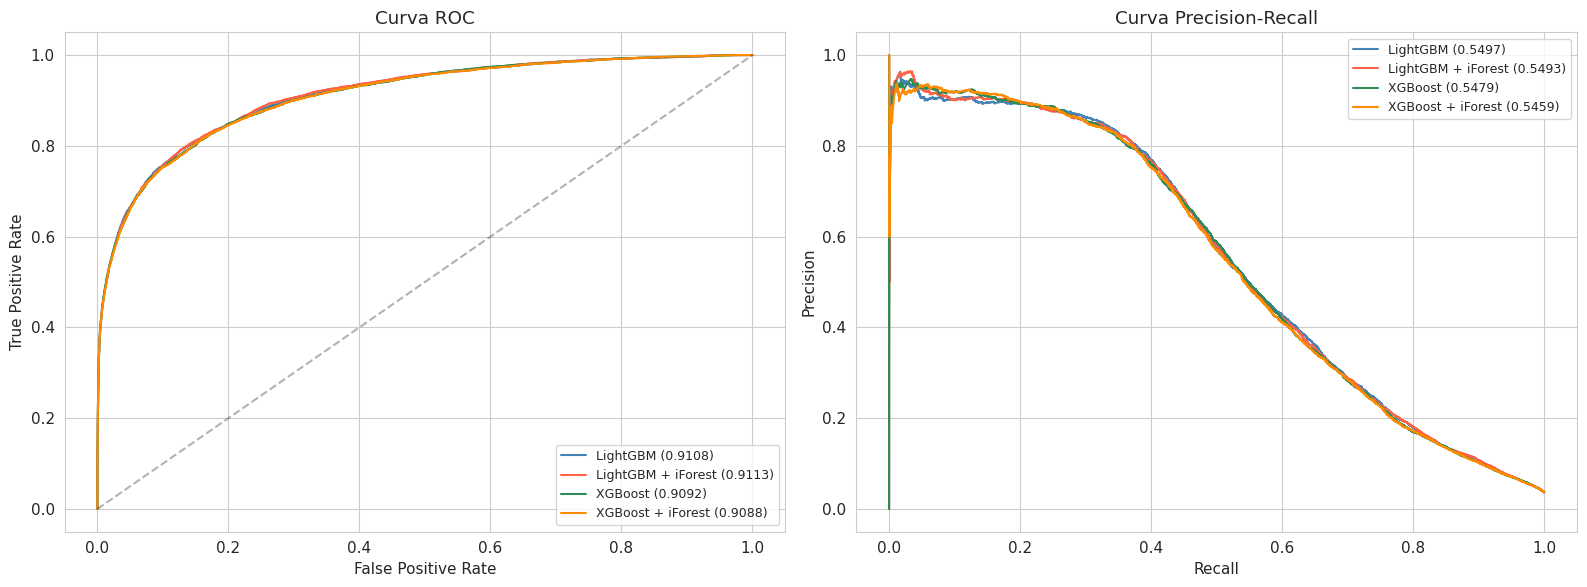

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ["steelblue", "tomato", "seagreen", "darkorange"]

for i, (name, config) in enumerate(trained_models.items()):
    model = config["model"]
    feats = config["features"]
    y_proba = model.predict_proba(X_test[feats])[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = benchmark_results[name]["auc_roc"]
    axes[0].plot(fpr, tpr, color=colors[i], label=f"{name} ({auc_val:.4f})")

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap_val = benchmark_results[name]["auc_pr"]
    axes[1].plot(rec, prec, color=colors[i], label=f"{name} ({ap_val:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Curva ROC")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Otimizacao por Custo

Em vez de otimizar por F1, otimizamos pelo custo total:
- **Falso negativo (fraude nao detectada):** custo = valor da transacao
- **Falso positivo (bloqueio indevido):** custo = revisao manual + risco churn
- **Verdadeiro positivo (fraude detectada):** economia = valor da transacao

In [0]:
COST_FP = 15.0    # custo medio de revisao manual por falso positivo (USD)
COST_CHURN = 50.0  # custo medio de churn por bloqueio indevido (USD)
FP_CHURN_RATE = 0.02  # 2% dos falsos positivos geram churn

COST_PER_FP = COST_FP + (FP_CHURN_RATE * COST_CHURN)

print(f"Custo por falso positivo: ${COST_PER_FP:.2f}")
print(f"  Revisao manual: ${COST_FP:.2f}")
print(f"  Churn esperado: ${FP_CHURN_RATE * COST_CHURN:.2f} "
      f"({FP_CHURN_RATE*100:.0f}% chance x ${COST_CHURN:.0f})")
print(f"Custo por falso negativo: valor da transacao (variavel)")

Custo por falso positivo: $16.00
  Revisao manual: $15.00
  Churn esperado: $1.00 (2% chance x $50)
Custo por falso negativo: valor da transacao (variavel)


In [0]:
best_model_name = bench_df.index[0]
best_config = trained_models[best_model_name]
best_model = best_config["model"]
best_feats = best_config["features"]

y_proba_test = best_model.predict_proba(X_test[best_feats])[:, 1]

thresholds = np.linspace(0.05, 0.95, 200)
cost_analysis = []

for t in thresholds:
    y_pred = (y_proba_test >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fn_amounts = test_amounts[(y_test == 1) & (y_pred == 0)]
    cost_fn = fn_amounts.sum()
    cost_fp = fp * COST_PER_FP
    savings = test_amounts[(y_test == 1) & (y_pred == 1)].sum()

    cost_analysis.append({
        "threshold": t,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "cost_fn": cost_fn,
        "cost_fp": cost_fp,
        "total_cost": cost_fn + cost_fp,
        "savings": savings,
        "net_cost": cost_fn + cost_fp - savings,
        "recall": recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred),
    })

cost_df = pd.DataFrame(cost_analysis)

In [0]:
optimal_cost_idx = cost_df["total_cost"].idxmin()
optimal_cost_t = cost_df.loc[optimal_cost_idx, "threshold"]
optimal_f1_t = best_config["threshold"]

print(f"Modelo: {best_model_name}")
print(f"\nThreshold otimizado por F1:    {optimal_f1_t:.3f}")
print(f"  Recall:     {cost_df.loc[cost_df['threshold'].sub(optimal_f1_t).abs().idxmin(), 'recall']:.4f}")
print(f"  Total Cost: ${cost_df.loc[cost_df['threshold'].sub(optimal_f1_t).abs().idxmin(), 'total_cost']:,.0f}")

print(f"\nThreshold otimizado por Custo: {optimal_cost_t:.3f}")
print(f"  Recall:     {cost_df.loc[optimal_cost_idx, 'recall']:.4f}")
print(f"  Total Cost: ${cost_df.loc[optimal_cost_idx, 'total_cost']:,.0f}")

cost_diff = (
    cost_df.loc[cost_df["threshold"].sub(optimal_f1_t).abs().idxmin(), "total_cost"]
    - cost_df.loc[optimal_cost_idx, "total_cost"]
)
print(f"\nEconomia com otimizacao por custo: ${cost_diff:,.0f}")

Modelo: LightGBM + iForest

Threshold otimizado por F1:    0.220
  Recall:     0.4658
  Total Cost: $745,534

Threshold otimizado por Custo: 0.050
  Recall:     0.7003
  Total Cost: $570,975

Economia com otimizacao por custo: $174,559


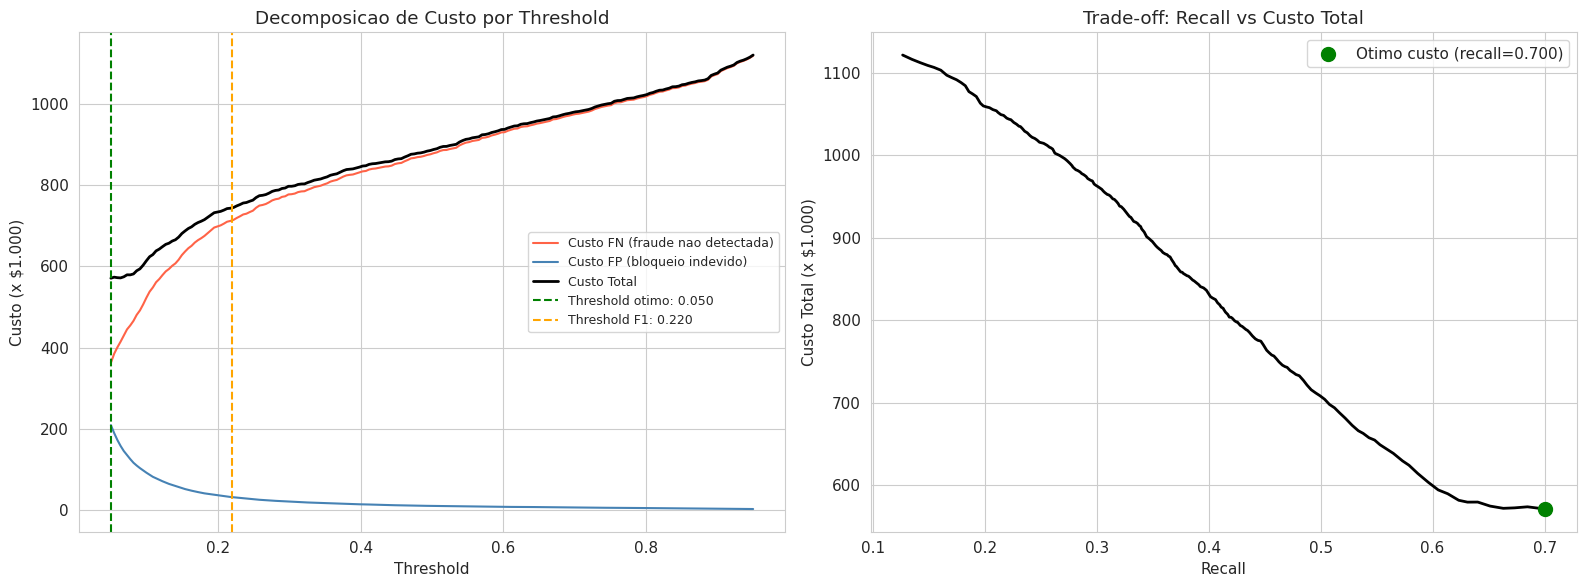

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(cost_df["threshold"], cost_df["cost_fn"] / 1e3,
             label="Custo FN (fraude nao detectada)", color="tomato")
axes[0].plot(cost_df["threshold"], cost_df["cost_fp"] / 1e3,
             label="Custo FP (bloqueio indevido)", color="steelblue")
axes[0].plot(cost_df["threshold"], cost_df["total_cost"] / 1e3,
             label="Custo Total", color="black", linewidth=2)
axes[0].axvline(optimal_cost_t, color="green", linestyle="--",
                label=f"Threshold otimo: {optimal_cost_t:.3f}")
axes[0].axvline(optimal_f1_t, color="orange", linestyle="--",
                label=f"Threshold F1: {optimal_f1_t:.3f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Custo (x $1.000)")
axes[0].set_title("Decomposicao de Custo por Threshold")
axes[0].legend(fontsize=9)

axes[1].plot(cost_df["recall"], cost_df["total_cost"] / 1e3,
             color="black", linewidth=2)
r_cost = cost_df.loc[optimal_cost_idx, "recall"]
c_cost = cost_df.loc[optimal_cost_idx, "total_cost"] / 1e3
axes[1].scatter([r_cost], [c_cost], color="green", s=100, zorder=5,
                label=f"Otimo custo (recall={r_cost:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Custo Total (x $1.000)")
axes[1].set_title("Trade-off: Recall vs Custo Total")
axes[1].legend()

plt.tight_layout()
plt.show()



## 8. Analise de Sensibilidade

O custo de FP ($16) e a funcao de custo de FN (valor da transacao) sao premissas.
Diferentes negocios tem custos diferentes. Esta secao mostra como o threshold
otimo e a economia mudam conforme essas premissas variam.

In [0]:
sensitivity_fp_costs = [5, 10, 16, 25, 50, 100]

thresholds = np.linspace(0.02, 0.95, 300)

sensitivity_results = []

for cost_fp_val in sensitivity_fp_costs:
    best_total = float("inf")
    best_t = 0.5
    best_recall = 0
    best_fp_count = 0
    best_fn_cost = 0

    for t in thresholds:
        y_pred = (y_proba_test >= t).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp_count, fn, tp = cm.ravel()

        fn_cost = test_amounts[(y_test == 1) & (y_pred == 0)].sum()
        fp_cost = fp_count * cost_fp_val
        total = fn_cost + fp_cost

        if total < best_total:
            best_total = total
            best_t = t
            best_recall = recall_score(y_test, y_pred)
            best_fp_count = fp_count
            best_fn_cost = fn_cost

    sensitivity_results.append({
        "cost_per_fp": cost_fp_val,
        "optimal_threshold": best_t,
        "recall": best_recall,
        "total_cost": best_total,
        "cost_fn": best_fn_cost,
        "cost_fp": best_fp_count * cost_fp_val,
        "n_fp": best_fp_count,
    })

sens_df = pd.DataFrame(sensitivity_results)

print("Analise de Sensibilidade: Custo por Falso Positivo")
print("=" * 75)
print(f"{'Custo FP':>10s} {'Threshold':>10s} {'Recall':>8s} "
      f"{'Custo FN':>12s} {'Custo FP':>12s} {'Total':>12s} {'N FPs':>8s}")
print("-" * 75)
for _, row in sens_df.iterrows():
    print(f"${row['cost_per_fp']:>8.0f} {row['optimal_threshold']:>10.3f} "
          f"{row['recall']:>8.4f} ${row['cost_fn']:>10,.0f} "
          f"${row['cost_fp']:>10,.0f} ${row['total_cost']:>10,.0f} "
          f"{row['n_fp']:>7,.0f}")

Analise de Sensibilidade: Custo por Falso Positivo
  Custo FP  Threshold   Recall     Custo FN     Custo FP        Total    N FPs
---------------------------------------------------------------------------
$       5      0.026   0.7932 $   242,601 $   129,505 $   372,106  25,901
$      10      0.042   0.7267 $   319,042 $   158,640 $   477,682  15,864
$      16      0.045   0.7167 $   334,261 $   235,024 $   569,285  14,689
$      25      0.079   0.6282 $   458,189 $   188,525 $   646,714   7,541
$      50      0.144   0.5294 $   614,387 $   174,750 $   789,137   3,495
$     100      0.322   0.4185 $   785,708 $   112,800 $   898,508   1,128


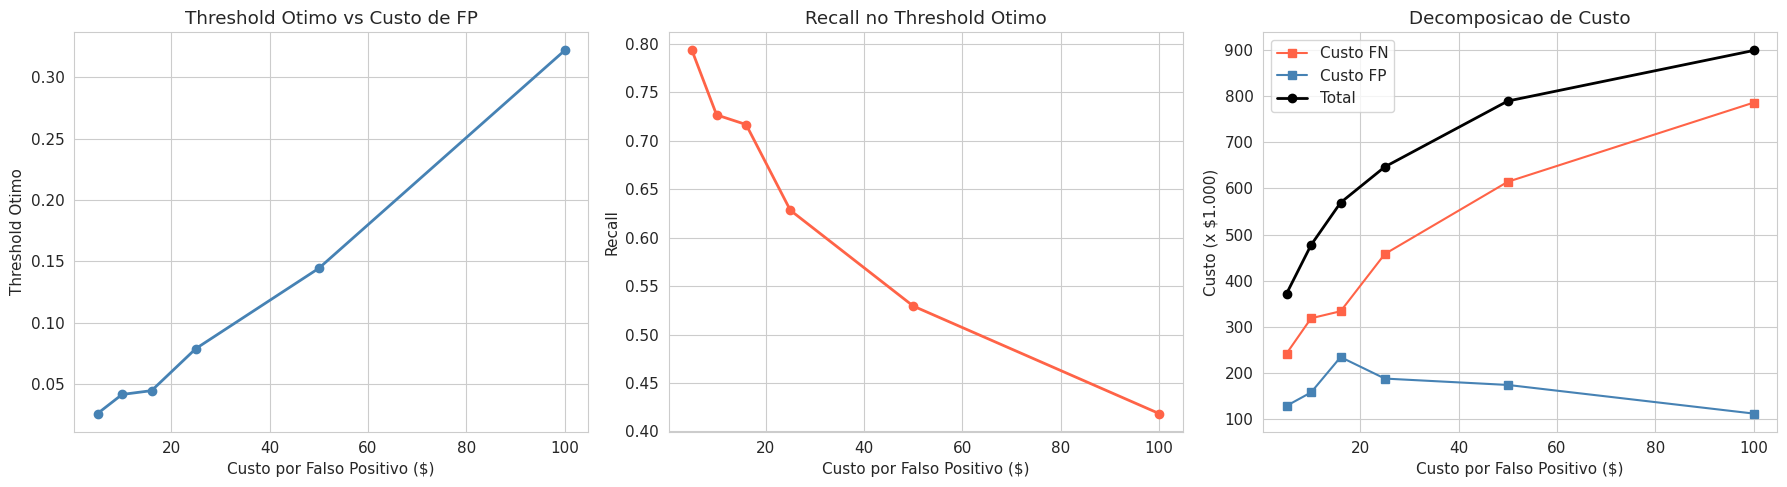

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(sens_df["cost_per_fp"], sens_df["optimal_threshold"],
             marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("Custo por Falso Positivo ($)")
axes[0].set_ylabel("Threshold Otimo")
axes[0].set_title("Threshold Otimo vs Custo de FP")

axes[1].plot(sens_df["cost_per_fp"], sens_df["recall"],
             marker="o", color="tomato", linewidth=2)
axes[1].set_xlabel("Custo por Falso Positivo ($)")
axes[1].set_ylabel("Recall")
axes[1].set_title("Recall no Threshold Otimo")

axes[2].plot(sens_df["cost_per_fp"], sens_df["cost_fn"] / 1e3,
             marker="s", color="tomato", label="Custo FN")
axes[2].plot(sens_df["cost_per_fp"], sens_df["cost_fp"] / 1e3,
             marker="s", color="steelblue", label="Custo FP")
axes[2].plot(sens_df["cost_per_fp"], sens_df["total_cost"] / 1e3,
             marker="o", color="black", linewidth=2, label="Total")
axes[2].set_xlabel("Custo por Falso Positivo ($)")
axes[2].set_ylabel("Custo (x $1.000)")
axes[2].set_title("Decomposicao de Custo")
axes[2].legend()

plt.tight_layout()
plt.show()

### 8.1 Sensibilidade ao Multiplicador de Custo de FN

Em alguns negocios, o custo de uma fraude nao detectada vai alem do valor
da transacao (multas regulatorias, dano reputacional, chargeback fees).

In [0]:
fn_multipliers = [0.5, 1.0, 1.5, 2.0, 3.0]

fn_mult_results = []
for mult in fn_multipliers:
    best_total = float("inf")
    best_t = 0.5
    best_recall = 0

    for t in thresholds:
        y_pred = (y_proba_test >= t).astype(int)
        cm = confusion_matrix(y_test, y_pred)
        tn, fp_count, fn, tp = cm.ravel()

        fn_cost = test_amounts[(y_test == 1) & (y_pred == 0)].sum() * mult
        fp_cost = fp_count * COST_PER_FP
        total = fn_cost + fp_cost

        if total < best_total:
            best_total = total
            best_t = t
            best_recall = recall_score(y_test, y_pred)

    fn_mult_results.append({
        "fn_multiplier": mult,
        "optimal_threshold": best_t,
        "recall": best_recall,
        "total_cost": best_total,
    })

fn_mult_df = pd.DataFrame(fn_mult_results)

print("\nSensibilidade ao multiplicador de custo FN")
print("(1.0 = so valor da transacao, 2.0 = valor + chargeback + multa)")
print("=" * 60)
for _, row in fn_mult_df.iterrows():
    print(f"  Mult={row['fn_multiplier']:.1f}x  |  Threshold={row['optimal_threshold']:.3f}  "
          f"|  Recall={row['recall']:.4f}  |  Custo=${row['total_cost']:,.0f}")


Sensibilidade ao multiplicador de custo FN
(1.0 = so valor da transacao, 2.0 = valor + chargeback + multa)
  Mult=0.5x  |  Threshold=0.088  |  Recall=0.6094  |  Custo=$348,304
  Mult=1.0x  |  Threshold=0.045  |  Recall=0.7167  |  Custo=$569,285
  Mult=1.5x  |  Threshold=0.042  |  Recall=0.7267  |  Custo=$732,386
  Mult=2.0x  |  Threshold=0.039  |  Recall=0.7365  |  Custo=$887,564
  Mult=3.0x  |  Threshold=0.026  |  Recall=0.7932  |  Custo=$1,142,218


## 9. Impacto por Segmento

Nem todas as transacoes tem o mesmo perfil de risco.
Analisamos como o modelo performa por tipo de produto, cartao e faixa de valor.

### 9.1 Performance por ProductCD

In [0]:
test_data_full = df_clean.loc[test_mask].copy()
test_data_full["anomaly_score"] = X_test["anomaly_score"].values
test_data_full["y_proba"] = y_proba_test
test_data_full["y_pred_f1"] = (y_proba_test >= optimal_f1_t).astype(int)
test_data_full["y_pred_cost"] = (y_proba_test >= optimal_cost_t).astype(int)

product_cd_map = label_encoders["ProductCD"]

segment_results = []

for prod_code in test_data_full["ProductCD"].unique():
    mask = test_data_full["ProductCD"] == prod_code
    subset = test_data_full[mask]
    y_true = subset["isFraud"]

    if y_true.sum() < 10:
        continue

    try:
        prod_label = product_cd_map.inverse_transform([prod_code])[0]
    except (ValueError, IndexError):
        prod_label = str(prod_code)

    for strategy, pred_col in [("F1", "y_pred_f1"), ("Custo", "y_pred_cost")]:
        y_pred = subset[pred_col]
        cm = confusion_matrix(y_true, y_pred)
        tn, fp_count, fn, tp = cm.ravel()

        fn_cost = subset.loc[(y_true == 1) & (y_pred == 0), "TransactionAmt"].sum()
        fp_cost = fp_count * COST_PER_FP

        segment_results.append({
            "ProductCD": prod_label,
            "strategy": strategy,
            "n_transactions": len(subset),
            "n_frauds": int(y_true.sum()),
            "fraud_rate": y_true.mean() * 100,
            "recall": recall_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred),
            "cost_fn": fn_cost,
            "cost_fp": fp_cost,
            "total_cost": fn_cost + fp_cost,
        })

seg_df = pd.DataFrame(segment_results)

print("Performance por ProductCD")
print("=" * 90)
for prod in seg_df["ProductCD"].unique():
    prod_data = seg_df[seg_df["ProductCD"] == prod]
    n_trans = prod_data.iloc[0]["n_transactions"]
    n_fraud = prod_data.iloc[0]["n_frauds"]
    fr = prod_data.iloc[0]["fraud_rate"]
    print(f"\n  ProductCD={prod} | {n_trans:,} transacoes | "
          f"{n_fraud:,} fraudes ({fr:.2f}%)")
    for _, row in prod_data.iterrows():
        print(f"    [{row['strategy']:>5s}] Recall={row['recall']:.4f} | "
              f"Precision={row['precision']:.4f} | "
              f"Custo FN=${row['cost_fn']:,.0f} | "
              f"Custo FP=${row['cost_fp']:,.0f} | "
              f"Total=${row['total_cost']:,.0f}")

Performance por ProductCD

  ProductCD=W | 164,100 transacoes | 3,333 fraudes (2.03%)
    [   F1] Recall=0.1830 | Precision=0.4781 | Custo FN=$612,492 | Custo FP=$10,656 | Total=$623,148
    [Custo] Recall=0.5143 | Precision=0.1859 | Custo FN=$319,856 | Custo FP=$120,080 | Total=$439,936

  ProductCD=C | 23,521 transacoes | 3,136 fraudes (13.33%)
    [   F1] Recall=0.7411 | Precision=0.7116 | Custo FN=$38,057 | Custo FP=$15,072 | Total=$53,129
    [Custo] Recall=0.8734 | Precision=0.4294 | Custo FN=$18,352 | Custo FP=$58,240 | Total=$76,592

  ProductCD=H | 5,643 transacoes | 351 fraudes (6.22%)
    [   F1] Recall=0.5470 | Precision=0.5066 | Custo FN=$15,101 | Custo FP=$2,992 | Total=$18,093
    [Custo] Recall=0.7664 | Precision=0.2289 | Custo FN=$4,916 | Custo FP=$14,496 | Total=$19,412

  ProductCD=R | 8,556 transacoes | 443 fraudes (5.18%)
    [   F1] Recall=0.6253 | Precision=0.7139 | Custo FN=$39,850 | Custo FP=$1,776 | Total=$41,626
    [Custo] Recall=0.8284 | Precision=0.3297 | 

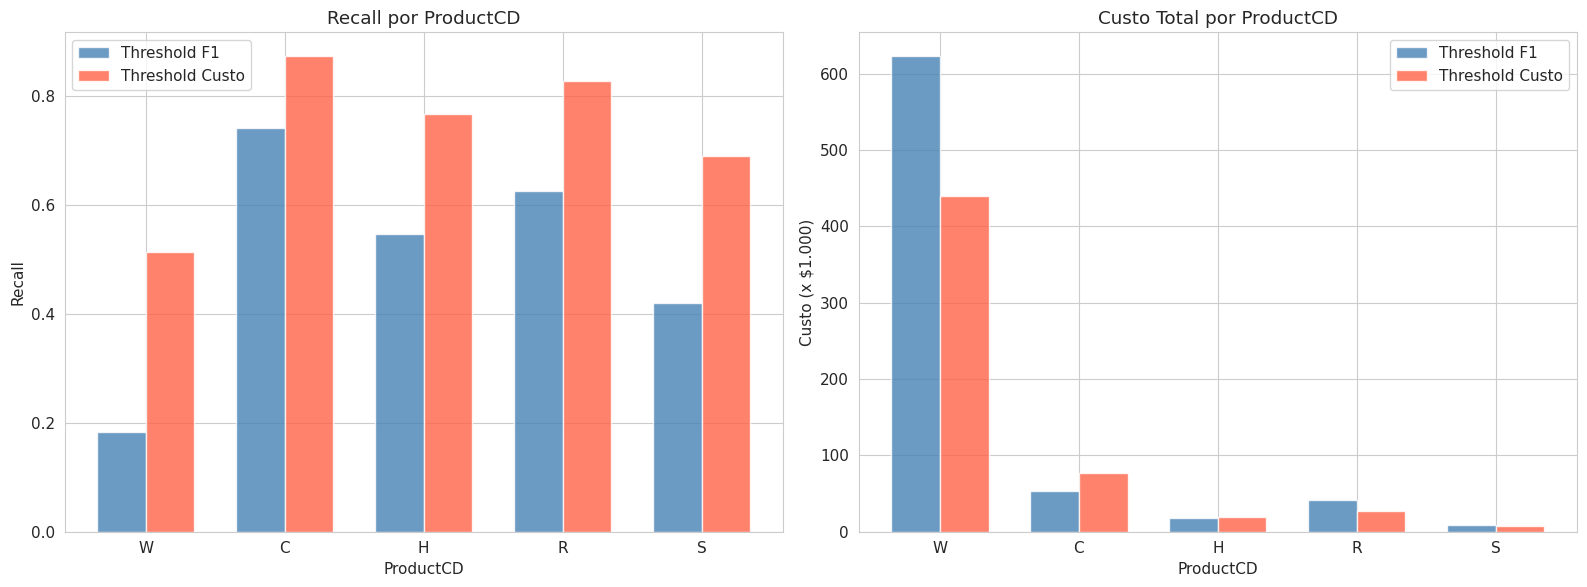

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

products = seg_df["ProductCD"].unique()
x = np.arange(len(products))
width = 0.35

for ax, metric, title in [
    (axes[0], "recall", "Recall por ProductCD"),
    (axes[1], "total_cost", "Custo Total por ProductCD"),
]:
    vals_f1 = [seg_df[(seg_df["ProductCD"] == p) & (seg_df["strategy"] == "F1")][metric].values[0]
               for p in products]
    vals_cost = [seg_df[(seg_df["ProductCD"] == p) & (seg_df["strategy"] == "Custo")][metric].values[0]
                 for p in products]

    if metric == "total_cost":
        vals_f1 = [v / 1e3 for v in vals_f1]
        vals_cost = [v / 1e3 for v in vals_cost]

    ax.bar(x - width / 2, vals_f1, width, label="Threshold F1", color="steelblue", alpha=0.8)
    ax.bar(x + width / 2, vals_cost, width, label="Threshold Custo", color="tomato", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(products)
    ax.set_xlabel("ProductCD")
    ylabel = "Custo (x $1.000)" if metric == "total_cost" else metric.capitalize()
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### 9.2 Performance por Faixa de Valor

In [0]:
test_data_full["amt_bucket"] = pd.cut(
    test_data_full["TransactionAmt"],
    bins=[0, 50, 150, 500, 2000, float("inf")],
    labels=["$0-50", "$50-150", "$150-500", "$500-2K", "$2K+"]
)

amt_results = []
for bucket in test_data_full["amt_bucket"].cat.categories:
    mask = test_data_full["amt_bucket"] == bucket
    subset = test_data_full[mask]
    y_true = subset["isFraud"]

    if y_true.sum() < 5:
        continue

    for strategy, pred_col in [("F1", "y_pred_f1"), ("Custo", "y_pred_cost")]:
        y_pred = subset[pred_col]
        cm = confusion_matrix(y_true, y_pred)
        tn, fp_count, fn, tp = cm.ravel()

        fn_cost = subset.loc[(y_true == 1) & (y_pred == 0), "TransactionAmt"].sum()
        fp_cost = fp_count * COST_PER_FP

        amt_results.append({
            "faixa": bucket,
            "strategy": strategy,
            "n_transactions": len(subset),
            "n_frauds": int(y_true.sum()),
            "fraud_rate": y_true.mean() * 100,
            "recall": recall_score(y_true, y_pred),
            "cost_fn": fn_cost,
            "cost_fp": fp_cost,
            "total_cost": fn_cost + fp_cost,
            "avg_fraud_amt": subset.loc[y_true == 1, "TransactionAmt"].mean(),
        })

amt_df = pd.DataFrame(amt_results)

print("Performance por Faixa de Valor")
print("=" * 95)
for bucket in amt_df["faixa"].unique():
    b_data = amt_df[amt_df["faixa"] == bucket]
    n_trans = b_data.iloc[0]["n_transactions"]
    n_fraud = b_data.iloc[0]["n_frauds"]
    fr = b_data.iloc[0]["fraud_rate"]
    avg_amt = b_data.iloc[0]["avg_fraud_amt"]
    print(f"\n  Faixa {bucket} | {n_trans:,} trans | "
          f"{n_fraud:,} fraudes ({fr:.2f}%) | "
          f"Valor medio fraude: ${avg_amt:,.0f}")
    for _, row in b_data.iterrows():
        print(f"    [{row['strategy']:>5s}] Recall={row['recall']:.4f} | "
              f"Custo FN=${row['cost_fn']:,.0f} | "
              f"Custo FP=${row['cost_fp']:,.0f} | "
              f"Total=${row['total_cost']:,.0f}")

Performance por Faixa de Valor

  Faixa $0-50 | 70,002 trans | 2,886 fraudes (4.12%) | Valor medio fraude: $29
    [   F1] Recall=0.5773 | Custo FN=$38,545 | Custo FP=$11,936 | Total=$50,481
    [Custo] Recall=0.7526 | Custo FN=$23,580 | Custo FP=$63,296 | Total=$86,876

  Faixa $50-150 | 93,132 trans | 2,785 fraudes (2.99%) | Valor medio fraude: $90
    [   F1] Recall=0.4259 | Custo FN=$144,453 | Custo FP=$10,016 | Total=$154,469
    [Custo] Recall=0.6460 | Custo FN=$87,185 | Custo FP=$74,224 | Total=$161,409

  Faixa $150-500 | 35,332 trans | 1,374 fraudes (3.89%) | Valor medio fraude: $278
    [   F1] Recall=0.3544 | Custo FN=$237,901 | Custo FP=$7,232 | Total=$245,133
    [Custo] Recall=0.6856 | Custo FN=$112,172 | Custo FP=$56,000 | Total=$168,172

  Faixa $500-2K | 7,399 trans | 474 fraudes (6.41%) | Valor medio fraude: $891
    [   F1] Recall=0.3692 | Custo FN=$255,219 | Custo FP=$1,552 | Total=$256,771
    [Custo] Recall=0.7595 | Custo FN=$103,788 | Custo FP=$14,512 | Total=$11

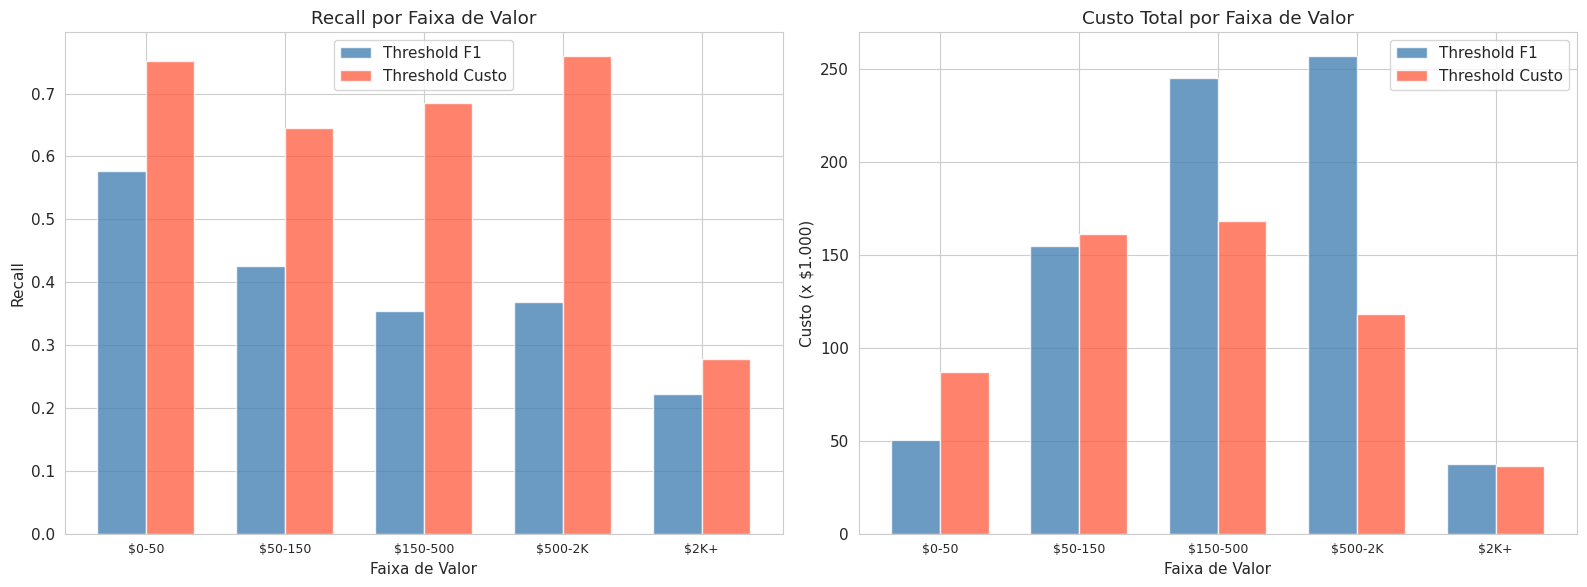

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

buckets = amt_df["faixa"].unique()
x = np.arange(len(buckets))

for ax, metric, title in [
    (axes[0], "recall", "Recall por Faixa de Valor"),
    (axes[1], "total_cost", "Custo Total por Faixa de Valor"),
]:
    vals_f1 = [amt_df[(amt_df["faixa"] == b) & (amt_df["strategy"] == "F1")][metric].values[0]
               for b in buckets]
    vals_cost = [amt_df[(amt_df["faixa"] == b) & (amt_df["strategy"] == "Custo")][metric].values[0]
                 for b in buckets]

    if metric == "total_cost":
        vals_f1 = [v / 1e3 for v in vals_f1]
        vals_cost = [v / 1e3 for v in vals_cost]

    ax.bar(x - width / 2, vals_f1, width, label="Threshold F1", color="steelblue", alpha=0.8)
    ax.bar(x + width / 2, vals_cost, width, label="Threshold Custo", color="tomato", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(buckets, fontsize=9)
    ax.set_xlabel("Faixa de Valor")
    ylabel = "Custo (x $1.000)" if metric == "total_cost" else metric.capitalize()
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## 10. Framework de Decisao em Cascata

Sistemas reais de fraude nao operam com decisao binaria (aprovar/bloquear).
A pratica da industria usa tres zonas de decisao: auto-aprovacao, revisao
manual e bloqueio automatico. A contribuicao aqui e otimizar os dois
thresholds simultaneamente por funcao de custo asimetrica, e priorizar
a fila de revisao pelo custo esperado de erro, nao pelo score bruto.

In [0]:
test_period_days = test_days.max() - test_days.min()

COST_REVIEW = 7.0         # custo de revisao manual por transacao (USD)
COST_AUTO_BLOCK_FP = 16.0 # custo de bloqueio automatico indevido (USD)
REVIEWER_CATCH_RATE = 0.95 # taxa de deteccao do analista humano
MAX_DAILY_REVIEWS = 500    # capacidade maxima de revisoes por dia

print("Parametros do Framework de Cascata")
print("=" * 55)
print(f"  Custo revisao manual:     ${COST_REVIEW:.2f}/transacao")
print(f"  Custo bloqueio indevido:  ${COST_AUTO_BLOCK_FP:.2f}/transacao")
print(f"  Taxa deteccao do revisor: {REVIEWER_CATCH_RATE:.0%}")
print(f"  Capacidade revisao:       {MAX_DAILY_REVIEWS} transacoes/dia")

Parametros do Framework de Cascata
  Custo revisao manual:     $7.00/transacao
  Custo bloqueio indevido:  $16.00/transacao
  Taxa deteccao do revisor: 95%
  Capacidade revisao:       500 transacoes/dia


In [0]:
def cascade_cost(y_true, y_proba, amounts, t_low, t_high,
                 cost_review=COST_REVIEW,
                 cost_block_fp=COST_AUTO_BLOCK_FP,
                 reviewer_catch=REVIEWER_CATCH_RATE):
    """
    Zona 1 (score < t_low): auto-aprovar
    Zona 2 (t_low <= score < t_high): revisao manual
    Zona 3 (score >= t_high): bloqueio automatico
    """
    zone_approve = y_proba < t_low
    zone_review = (y_proba >= t_low) & (y_proba < t_high)
    zone_block = y_proba >= t_high

    fn_approve = amounts[(y_true == 1) & zone_approve].sum()

    n_review = zone_review.sum()
    review_operational = n_review * cost_review
    fn_review = amounts[(y_true == 1) & zone_review].sum() * (1 - reviewer_catch)

    fp_block = ((y_true == 0) & zone_block).sum() * cost_block_fp

    total = fn_approve + review_operational + fn_review + fp_block

    return {
        "t_low": t_low,
        "t_high": t_high,
        "cost_fn_approve": fn_approve,
        "cost_review_ops": review_operational,
        "cost_fn_review": fn_review,
        "cost_fp_block": fp_block,
        "total_cost": total,
        "n_auto_approve": int(zone_approve.sum()),
        "n_review": int(n_review),
        "n_auto_block": int(zone_block.sum()),
        "n_fraud_missed": int(((y_true == 1) & zone_approve).sum()),
        "n_fraud_caught_review": int(((y_true == 1) & zone_review).sum()),
        "n_fraud_blocked": int(((y_true == 1) & zone_block).sum()),
    }

In [0]:
t_values = np.linspace(0.01, 0.95, 200)

cascade_results = []
for t_low in t_values:
    for t_high in t_values:
        if t_high <= t_low:
            continue
        result = cascade_cost(
            y_test.values, y_proba_test, test_amounts.values,
            t_low, t_high
        )
        cascade_results.append(result)

cascade_df = pd.DataFrame(cascade_results)

best_cascade_idx = cascade_df["total_cost"].idxmin()
best_cascade = cascade_df.loc[best_cascade_idx]

print("Otimizacao de Cascata: Resultado")
print("=" * 65)
print(f"\n  Threshold baixo (auto-aprovar < t): {best_cascade['t_low']:.3f}")
print(f"  Threshold alto (auto-bloquear >= t): {best_cascade['t_high']:.3f}")
print(f"\n  Distribuicao de transacoes:")
print(f"    Auto-aprovar: {best_cascade['n_auto_approve']:>8,.0f} "
      f"({best_cascade['n_auto_approve']/len(y_test)*100:.1f}%)")
print(f"    Revisao:      {best_cascade['n_review']:>8,.0f} "
      f"({best_cascade['n_review']/len(y_test)*100:.1f}%)")
print(f"    Auto-bloquear:{best_cascade['n_auto_block']:>8,.0f} "
      f"({best_cascade['n_auto_block']/len(y_test)*100:.1f}%)")
print(f"\n  Decomposicao de custo:")
print(f"    Fraudes perdidas (auto-approve): ${best_cascade['cost_fn_approve']:>12,.0f}")
print(f"    Operacao de revisao:             ${best_cascade['cost_review_ops']:>12,.0f}")
print(f"    Fraudes que revisor perdeu:       ${best_cascade['cost_fn_review']:>12,.0f}")
print(f"    Bloqueios indevidos:             ${best_cascade['cost_fp_block']:>12,.0f}")
print(f"    TOTAL CASCATA:                   ${best_cascade['total_cost']:>12,.0f}")

Otimizacao de Cascata: Resultado

  Threshold baixo (auto-aprovar < t): 0.038
  Threshold alto (auto-bloquear >= t): 0.322

  Distribuicao de transacoes:
    Auto-aprovar:  183,763 (88.9%)
    Revisao:        18,644 (9.0%)
    Auto-bloquear:   4,282 (2.1%)

  Decomposicao de custo:
    Fraudes perdidas (auto-approve): $     303,801
    Operacao de revisao:             $     130,508
    Fraudes que revisor perdeu:       $      24,095
    Bloqueios indevidos:             $      18,048
    TOTAL CASCATA:                   $     476,453


In [0]:
cost_binary_f1 = cost_df.loc[
    cost_df["threshold"].sub(optimal_f1_t).abs().idxmin(), "total_cost"
]
cost_binary_opt = cost_df.loc[
    cost_df["threshold"].sub(optimal_cost_t).abs().idxmin(), "total_cost"
]
cost_cascade_opt = best_cascade["total_cost"]

print("Comparacao de Estrategias de Decisao")
print("=" * 65)
print(f"\n  {'Estrategia':<35s} {'Custo Total':>12s} {'vs F1':>10s}")
print(f"  {'-'*58}")
print(f"  {'Binario (threshold F1)':<35s} ${cost_binary_f1:>11,.0f} {'baseline':>10s}")
print(f"  {'Binario (threshold custo)':<35s} ${cost_binary_opt:>11,.0f} "
      f"-{(cost_binary_f1 - cost_binary_opt)/cost_binary_f1*100:.1f}%")
print(f"  {'Cascata (3 zonas otimizada)':<35s} ${cost_cascade_opt:>11,.0f} "
      f"-{(cost_binary_f1 - cost_cascade_opt)/cost_binary_f1*100:.1f}%")

savings_cascade_vs_binary = cost_binary_opt - cost_cascade_opt
savings_cascade_vs_f1 = cost_binary_f1 - cost_cascade_opt
print(f"\n  Economia adicional cascata vs binario otimizado: "
      f"${savings_cascade_vs_binary:,.0f}")
print(f"  Economia total cascata vs F1: "
      f"${savings_cascade_vs_f1:,.0f} "
      f"({savings_cascade_vs_f1/cost_binary_f1*100:.1f}%)")

Comparacao de Estrategias de Decisao

  Estrategia                           Custo Total      vs F1
  ----------------------------------------------------------
  Binario (threshold F1)              $    745,534   baseline
  Binario (threshold custo)           $    570,975 -23.4%
  Cascata (3 zonas otimizada)         $    476,453 -36.1%

  Economia adicional cascata vs binario otimizado: $94,523
  Economia total cascata vs F1: $269,082 (36.1%)


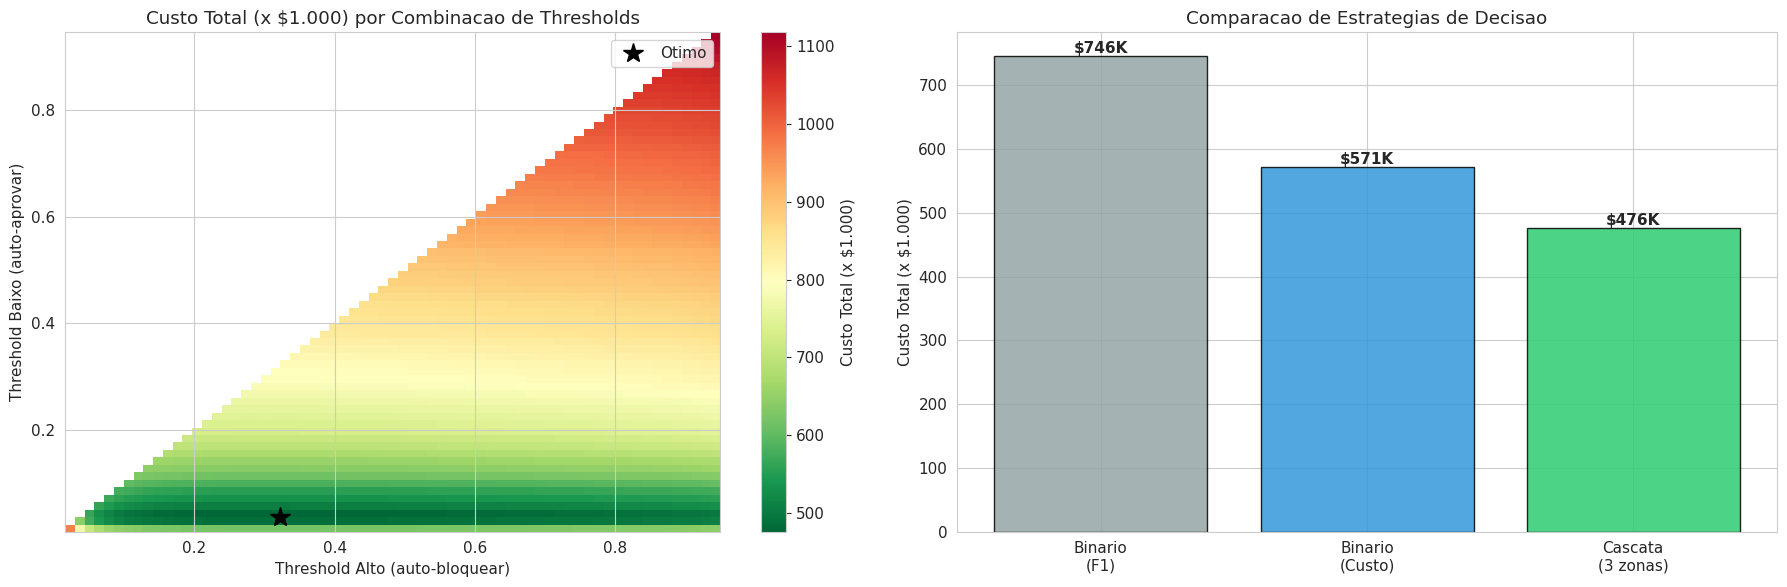

In [0]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

t_low_vals = sorted(cascade_df["t_low"].unique())
t_high_vals = sorted(cascade_df["t_high"].unique())
t_low_sample = t_low_vals[::max(1, len(t_low_vals) // 50)]
t_high_sample = t_high_vals[::max(1, len(t_high_vals) // 50)]

pivot_sampled = cascade_df[
    cascade_df["t_low"].isin(t_low_sample) &
    cascade_df["t_high"].isin(t_high_sample)
].pivot_table(
    index="t_low", columns="t_high", values="total_cost", aggfunc="min"
)

im = axes[0].imshow(
    pivot_sampled.values / 1e3,
    aspect="auto",
    origin="lower",
    cmap="RdYlGn_r",
    extent=[
        pivot_sampled.columns.min(), pivot_sampled.columns.max(),
        pivot_sampled.index.min(), pivot_sampled.index.max(),
    ],
)
axes[0].plot(
    best_cascade["t_high"], best_cascade["t_low"],
    "k*", markersize=15, label="Otimo"
)
axes[0].set_xlabel("Threshold Alto (auto-bloquear)")
axes[0].set_ylabel("Threshold Baixo (auto-aprovar)")
axes[0].set_title("Custo Total (x $1.000) por Combinacao de Thresholds")
axes[0].legend()
plt.colorbar(im, ax=axes[0], label="Custo Total (x $1.000)")

strategies = ["Binario\n(F1)", "Binario\n(Custo)", "Cascata\n(3 zonas)"]
costs = [cost_binary_f1 / 1e3, cost_binary_opt / 1e3, cost_cascade_opt / 1e3]
colors = ["#95a5a6", "#3498db", "#2ecc71"]

bars = axes[1].bar(strategies, costs, color=colors, edgecolor="black", alpha=0.85)
for bar, cost in zip(bars, costs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
        f"${cost:,.0f}K", ha="center", fontsize=11, fontweight="bold"
    )
axes[1].set_ylabel("Custo Total (x $1.000)")
axes[1].set_title("Comparacao de Estrategias de Decisao")

plt.tight_layout()
plt.savefig("/tmp/cascade_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 10.1 Priorizacao da Fila de Revisao por Custo Esperado

A fila de revisao nao e ordenada por score (probabilidade de fraude), mas
por custo esperado de erro: `expected_cost = score * transaction_amount`.
Uma transacao de $2.000 com score 0.15 tem prioridade sobre uma de $30
com score 0.40, porque o impacto financeiro de errar na primeira e maior.

In [0]:
zone_review_mask = (
    (y_proba_test >= best_cascade["t_low"]) &
    (y_proba_test < best_cascade["t_high"])
)

review_queue = pd.DataFrame({
    "score": y_proba_test[zone_review_mask],
    "amount": test_amounts.values[zone_review_mask],
    "is_fraud": y_test.values[zone_review_mask],
})
review_queue["expected_cost"] = review_queue["score"] * review_queue["amount"]

review_queue_by_score = review_queue.sort_values("score", ascending=False)
review_queue_by_cost = review_queue.sort_values("expected_cost", ascending=False)

daily_transactions_in_review = len(review_queue) / test_period_days
capacities = [100, 200, 500, 1000, int(daily_transactions_in_review)]

print("Priorizacao da Fila de Revisao: Score vs Custo Esperado")
print("=" * 80)
print(f"\n  Transacoes na zona de revisao: {len(review_queue):,}")
print(f"  Media diaria: {daily_transactions_in_review:,.0f}")
print(f"  Fraudes na zona de revisao: {review_queue['is_fraud'].sum():,}")

print(f"\n  {'Capacidade':>12s} | {'--- Por Score ---':>20s} | "
      f"{'--- Por Custo Esperado ---':>28s} | {'Ganho':>8s}")
print(f"  {'(reviews/dia)':>12s} | {'Fraudes':>8s} {'Valor ($)':>10s} | "
      f"{'Fraudes':>8s} {'Valor ($)':>18s} | {'':>8s}")
print(f"  {'-'*75}")

priority_results = []
for cap in capacities:
    total_reviews = min(int(cap * test_period_days), len(review_queue))

    top_by_score = review_queue_by_score.head(total_reviews)
    fraud_by_score = top_by_score["is_fraud"].sum()
    value_by_score = top_by_score.loc[
        top_by_score["is_fraud"] == 1, "amount"
    ].sum()

    top_by_cost = review_queue_by_cost.head(total_reviews)
    fraud_by_cost = top_by_cost["is_fraud"].sum()
    value_by_cost = top_by_cost.loc[
        top_by_cost["is_fraud"] == 1, "amount"
    ].sum()

    gain = value_by_cost - value_by_score
    print(f"  {cap:>12,d} | {fraud_by_score:>8,d} ${value_by_score:>9,.0f} | "
          f"{fraud_by_cost:>8,d} ${value_by_cost:>17,.0f} | "
          f"${gain:>+7,.0f}")

    priority_results.append({
        "capacity_daily": cap,
        "reviews_total": total_reviews,
        "fraud_score": fraud_by_score,
        "value_score": value_by_score,
        "fraud_cost": fraud_by_cost,
        "value_cost": value_by_cost,
        "gain": gain,
    })

priority_df = pd.DataFrame(priority_results)

Priorizacao da Fila de Revisao: Score vs Custo Esperado

  Transacoes na zona de revisao: 18,644
  Media diaria: 260
  Fraudes na zona de revisao: 2,410

    Capacidade |    --- Por Score --- |   --- Por Custo Esperado --- |    Ganho
  (reviews/dia) |  Fraudes  Valor ($) |  Fraudes          Valor ($) |         
  ---------------------------------------------------------------------------
           100 |    1,476 $  306,385 |    1,153 $          409,614 | $+103,229
           200 |    2,155 $  429,496 |    2,014 $          471,218 | $+41,722
           500 |    2,410 $  481,907 |    2,410 $          481,907 | $     +0
         1,000 |    2,410 $  481,907 |    2,410 $          481,907 | $     +0
           259 |    2,404 $  480,585 |    2,410 $          481,907 | $ +1,322


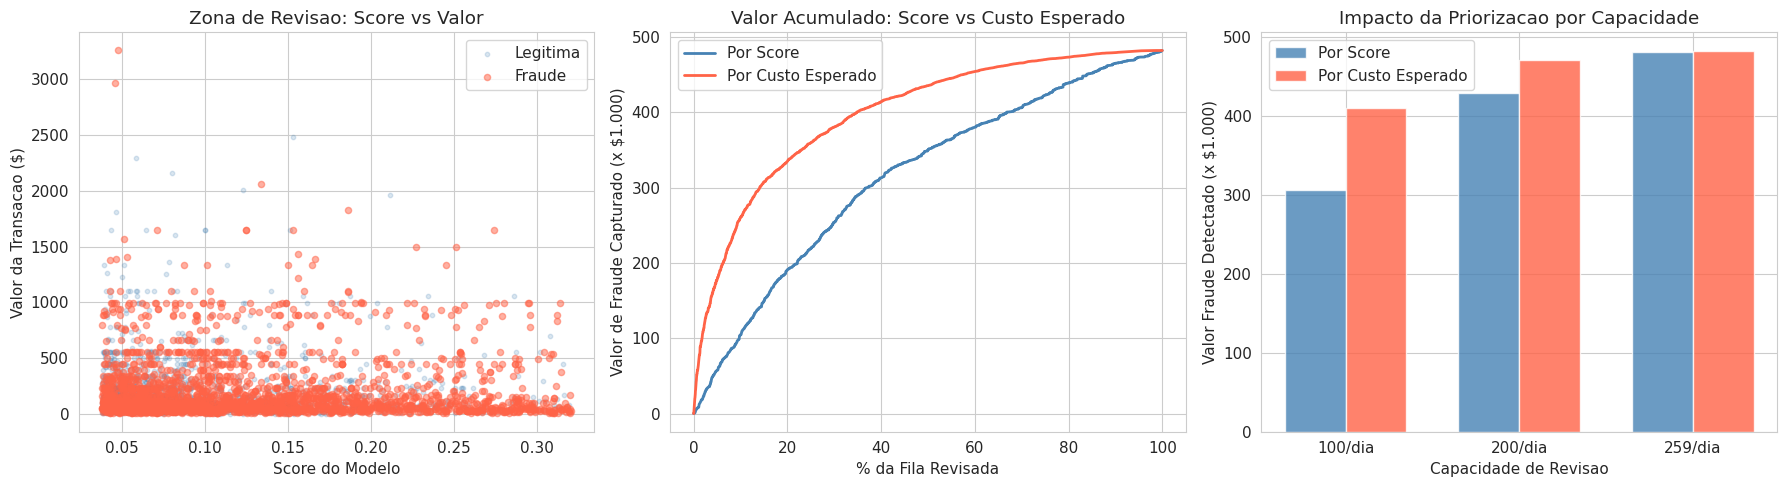

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: score vs amount na zona de revisao
ax = axes[0]
n_sample = min(2000, len(review_queue[review_queue["is_fraud"] == 0]))
legit = review_queue[review_queue["is_fraud"] == 0].sample(
    n_sample, random_state=42
)
fraud = review_queue[review_queue["is_fraud"] == 1]

ax.scatter(legit["score"], legit["amount"], alpha=0.2, s=10,
           color="steelblue", label="Legitima")
ax.scatter(fraud["score"], fraud["amount"], alpha=0.5, s=20,
           color="tomato", label="Fraude")
ax.set_xlabel("Score do Modelo")
ax.set_ylabel("Valor da Transacao ($)")
ax.set_title("Zona de Revisao: Score vs Valor")
ax.legend()

# Curva de valor capturado acumulado
ax = axes[1]
step = max(1, len(review_queue) // 3000)

cum_val_score = np.cumsum(
    review_queue_by_score["is_fraud"].values
    * review_queue_by_score["amount"].values
)
cum_val_cost = np.cumsum(
    review_queue_by_cost["is_fraud"].values
    * review_queue_by_cost["amount"].values
)
x_pct = np.arange(len(cum_val_score)) / len(cum_val_score) * 100

ax.plot(x_pct[::step], cum_val_score[::step] / 1e3,
        color="steelblue", linewidth=2, label="Por Score")
ax.plot(x_pct[::step], cum_val_cost[::step] / 1e3,
        color="tomato", linewidth=2, label="Por Custo Esperado")
ax.set_xlabel("% da Fila Revisada")
ax.set_ylabel("Valor de Fraude Capturado (x $1.000)")
ax.set_title("Valor Acumulado: Score vs Custo Esperado")
ax.legend()

# Bar: ganho por capacidade
ax = axes[2]
cap_plot = priority_df[priority_df["capacity_daily"] < daily_transactions_in_review]
if len(cap_plot) > 0:
    x = np.arange(len(cap_plot))
    width = 0.35
    ax.bar(x - width / 2, cap_plot["value_score"] / 1e3, width,
           label="Por Score", color="steelblue", alpha=0.8)
    ax.bar(x + width / 2, cap_plot["value_cost"] / 1e3, width,
           label="Por Custo Esperado", color="tomato", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(c)}/dia" for c in cap_plot["capacity_daily"]])
    ax.set_xlabel("Capacidade de Revisao")
    ax.set_ylabel("Valor Fraude Detectado (x $1.000)")
    ax.set_title("Impacto da Priorizacao por Capacidade")
    ax.legend()

plt.tight_layout()
plt.savefig("/tmp/cascade_prioritization.png", dpi=150, bbox_inches="tight")
plt.show()

In [0]:
def cascade_cost_with_capacity(
    y_true, y_proba, amounts, t_low, t_high,
    daily_capacity, period_days,
    cost_review=COST_REVIEW,
    cost_block_fp=COST_AUTO_BLOCK_FP,
    reviewer_catch=REVIEWER_CATCH_RATE,
    prioritize_by="expected_cost",
):
    zone_approve = y_proba < t_low
    zone_review = (y_proba >= t_low) & (y_proba < t_high)
    zone_block = y_proba >= t_high

    fn_approve = amounts[(y_true == 1) & zone_approve].sum()
    fp_block = ((y_true == 0) & zone_block).sum() * cost_block_fp

    review_idx = np.where(zone_review)[0]
    total_capacity = int(daily_capacity * period_days)

    if len(review_idx) <= total_capacity:
        review_op = len(review_idx) * cost_review
        fn_review = amounts[(y_true == 1) & zone_review].sum() * (1 - reviewer_catch)
        fn_overflow = 0.0
        n_overflow = 0
    else:
        if prioritize_by == "expected_cost":
            priority = y_proba[review_idx] * amounts[review_idx]
        else:
            priority = y_proba[review_idx]

        sorted_order = np.argsort(-priority)
        reviewed_idx = review_idx[sorted_order[:total_capacity]]
        overflow_idx = review_idx[sorted_order[total_capacity:]]

        review_op = total_capacity * cost_review
        fn_review = (
            amounts[reviewed_idx][(y_true[reviewed_idx] == 1)].sum()
            * (1 - reviewer_catch)
        )
        fn_overflow = amounts[overflow_idx][(y_true[overflow_idx] == 1)].sum()
        n_overflow = len(overflow_idx)

    total = fn_approve + review_op + fn_review + fn_overflow + fp_block

    return {
        "total_cost": total,
        "n_reviewed": min(len(review_idx), total_capacity),
        "n_overflow": n_overflow,
    }


print("Impacto da Restricao de Capacidade")
print("=" * 75)
print(f"\n  Thresholds: t_low={best_cascade['t_low']:.3f}, "
      f"t_high={best_cascade['t_high']:.3f}")
print(f"  Revisoes necessarias: "
      f"{best_cascade['n_review']/test_period_days:,.0f}/dia")

print(f"\n  {'Capacidade':>14s} | {'Por Score':>14s} | "
      f"{'Por Custo Esp.':>14s} | {'Economia':>10s}")
print(f"  {'-'*58}")

for cap in [100, 200, 500, 1000]:
    res_score = cascade_cost_with_capacity(
        y_test.values, y_proba_test, test_amounts.values,
        best_cascade["t_low"], best_cascade["t_high"],
        cap, test_period_days, prioritize_by="score",
    )
    res_cost = cascade_cost_with_capacity(
        y_test.values, y_proba_test, test_amounts.values,
        best_cascade["t_low"], best_cascade["t_high"],
        cap, test_period_days, prioritize_by="expected_cost",
    )
    diff = res_score["total_cost"] - res_cost["total_cost"]
    print(f"  {cap:>10,d}/dia | ${res_score['total_cost']:>13,.0f} | "
          f"${res_cost['total_cost']:>13,.0f} | ${diff:>+9,.0f}")

print(f"\n  {'Sem limite':>14s} | ${best_cascade['total_cost']:>13,.0f} | "
      f"${best_cascade['total_cost']:>13,.0f} | ${'0':>9s}")

Impacto da Restricao de Capacidade

  Thresholds: t_low=0.038, t_high=0.322
  Revisoes necessarias: 260/dia

      Capacidade |      Por Score | Por Custo Esp. |   Economia
  ----------------------------------------------------------
         100/dia | $      562,888 | $      464,820 | $  +98,067
         200/dia | $      496,136 | $      456,500 | $  +39,636
         500/dia | $      476,453 | $      476,453 | $       +0
       1,000/dia | $      476,453 | $      476,453 | $       +0

      Sem limite | $      476,453 | $      476,453 | $        0


## 11. Simulacao de Volume e Projecao Financeira

Projecao para escalas reais de operacao comparando as tres estrategias:
binario F1, binario custo-otimizado e cascata 3 zonas.

In [0]:
test_period_days = test_data_full["TransactionDay"].max() - test_data_full["TransactionDay"].min()
test_n_trans = len(test_data_full)
test_n_fraud = test_data_full["isFraud"].sum()

daily_trans = test_n_trans / test_period_days
daily_fraud = test_n_fraud / test_period_days
avg_fraud_amt = test_data_full.loc[
    test_data_full["isFraud"] == 1, "TransactionAmt"
].mean()

cost_f1_row = cost_df.loc[cost_df["threshold"].sub(optimal_f1_t).abs().idxmin()]
cost_opt_row = cost_df.loc[cost_df["threshold"].sub(optimal_cost_t).abs().idxmin()]

daily_cost_f1 = cost_f1_row["total_cost"] / test_period_days
daily_cost_binary = cost_opt_row["total_cost"] / test_period_days
daily_cost_cascade = cost_cascade_opt / test_period_days

daily_savings_binary = daily_cost_f1 - daily_cost_binary
daily_savings_cascade = daily_cost_f1 - daily_cost_cascade

scenarios = {
    "Dataset (teste)": {"multiplier": 1, "period_days": test_period_days},
    "Operacao media (5K/dia)": {
        "multiplier": 5000 / daily_trans, "period_days": 365,
    },
    "Operacao grande (50K/dia)": {
        "multiplier": 50000 / daily_trans, "period_days": 365,
    },
    "Marketplace (500K/dia)": {
        "multiplier": 500000 / daily_trans, "period_days": 365,
    },
}

print("Projecao Financeira: Tres Estrategias")
print("=" * 90)
print(f"\nPremissas base (periodo de teste):")
print(f"  Transacoes/dia: {daily_trans:,.0f} | Fraudes/dia: {daily_fraud:,.0f}")
print(f"  Valor medio fraude: ${avg_fraud_amt:,.0f}")

print(f"\n  {'Cenario':<30s} | {'Trans/dia':>10s} | "
      f"{'Econ. Binario':>14s} | {'Econ. Cascata':>14s} | {'Delta':>10s}")
print(f"  {'-'*85}")

projection_data = []
for name, config in scenarios.items():
    mult = config["multiplier"]
    days = config["period_days"]

    annual_binary = daily_savings_binary * mult * days
    annual_cascade = daily_savings_cascade * mult * days
    delta = annual_cascade - annual_binary

    trans_per_day = daily_trans * mult
    print(f"  {name:<30s} | {trans_per_day:>9,.0f} | "
          f"${annual_binary:>13,.0f} | ${annual_cascade:>13,.0f} | "
          f"${delta:>+9,.0f}")

    projection_data.append({
        "cenario": name,
        "trans_dia": trans_per_day,
        "economia_binario": annual_binary,
        "economia_cascata": annual_cascade,
    })

Projecao Financeira: Tres Estrategias

Premissas base (periodo de teste):
  Transacoes/dia: 2,882 | Fraudes/dia: 105
  Valor medio fraude: $158

  Cenario                        |  Trans/dia |  Econ. Binario |  Econ. Cascata |      Delta
  -------------------------------------------------------------------------------------
  Dataset (teste)                |     2,882 | $      174,559 | $      269,082 | $  +94,523
  Operacao media (5K/dia)        |     5,000 | $    1,541,304 | $    2,375,910 | $ +834,606
  Operacao grande (50K/dia)      |    50,000 | $   15,413,040 | $   23,759,097 | $+8,346,057
  Marketplace (500K/dia)         |   500,000 | $  154,130,402 | $  237,590,975 | $+83,460,573


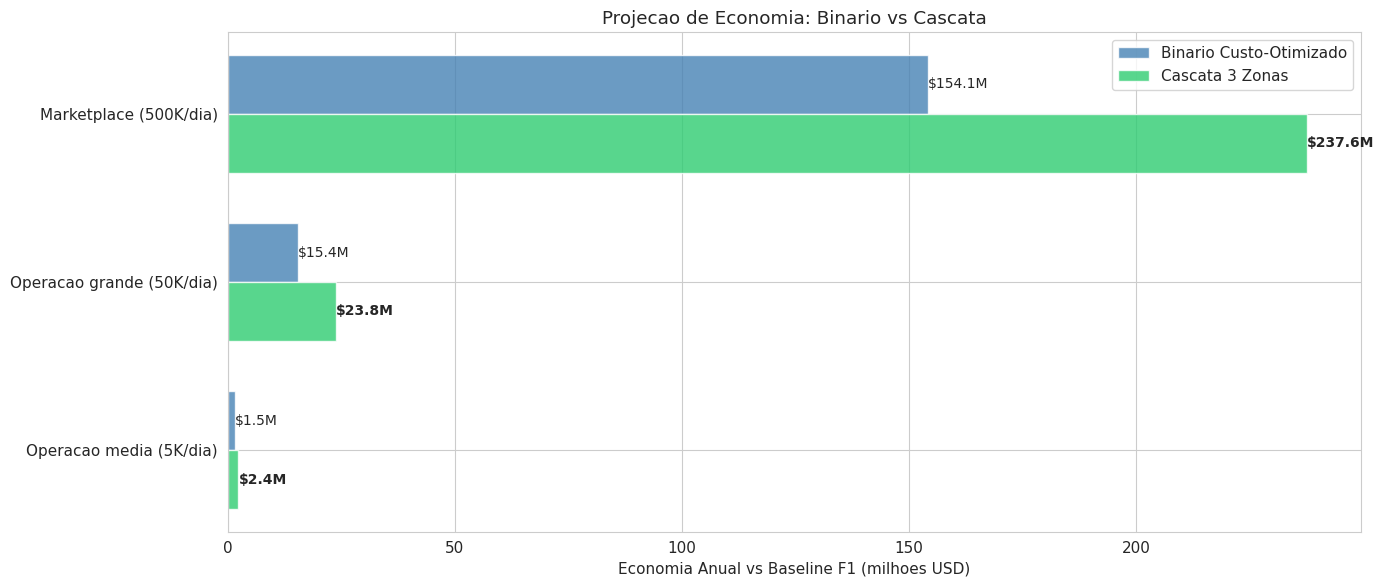

In [0]:
proj_df = pd.DataFrame(projection_data)
proj_plot = proj_df[proj_df["cenario"] != "Dataset (teste)"]

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(proj_plot))
width = 0.35

bars1 = ax.barh(x + width / 2, proj_plot["economia_binario"] / 1e6,
                width, label="Binario Custo-Otimizado", color="steelblue", alpha=0.8)
bars2 = ax.barh(x - width / 2, proj_plot["economia_cascata"] / 1e6,
                width, label="Cascata 3 Zonas", color="#2ecc71", alpha=0.8)

for bar, val in zip(bars1, proj_plot["economia_binario"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"${val / 1e6:,.1f}M", va="center", fontsize=10)
for bar, val in zip(bars2, proj_plot["economia_cascata"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"${val / 1e6:,.1f}M", va="center", fontsize=10, fontweight="bold")

ax.set_yticks(x)
ax.set_yticklabels(proj_plot["cenario"])
ax.set_xlabel("Economia Anual vs Baseline F1 (milhoes USD)")
ax.set_title("Projecao de Economia: Binario vs Cascata")
ax.legend()

plt.tight_layout()
plt.savefig("/tmp/projection_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 11.1 Analise de Break-even

In [0]:
ml_system_monthly_cost = 2500

savings_per_trans_binary = daily_savings_binary / daily_trans
savings_per_trans_cascade = daily_savings_cascade / daily_trans

breakeven_binary = ml_system_monthly_cost / 30 / savings_per_trans_binary
breakeven_cascade = ml_system_monthly_cost / 30 / savings_per_trans_cascade

print("Analise de Break-even")
print("=" * 60)
print(f"  Custo mensal do sistema ML: ${ml_system_monthly_cost:,.0f}")
print(f"\n  {'Metrica':<35s} {'Binario':>12s} {'Cascata':>12s}")
print(f"  {'-'*60}")
print(f"  {'Economia por transacao':<35s} "
      f"${savings_per_trans_binary:>11.4f} "
      f"${savings_per_trans_cascade:>11.4f}")
print(f"  {'Break-even (trans/dia)':<35s} "
      f"{breakeven_binary:>12,.0f} {breakeven_cascade:>12,.0f}")
print(f"  {'Break-even (trans/mes)':<35s} "
      f"{breakeven_binary * 30:>12,.0f} {breakeven_cascade * 30:>12,.0f}")

Analise de Break-even
  Custo mensal do sistema ML: $2,500

  Metrica                                  Binario      Cascata
  ------------------------------------------------------------
  Economia por transacao              $     0.8446 $     1.3019
  Break-even (trans/dia)                        99           64
  Break-even (trans/mes)                     2,960        1,920


## 12. Resumo Executivo

In [0]:
print("=" * 70)
print("RESUMO EXECUTIVO")
print("Deteccao de Fraude CNP com Otimizacao de Custo e Decisao em Cascata")
print("=" * 70)

print(f"\n1. DATASET")
print(f"   IEEE-CIS Fraud Detection (Vesta Corporation)")
print(f"   {len(df):,} transacoes e-commerce | {len(feature_cols)} features")
print(f"   Taxa de fraude: {fraud_rate:.2f}% | Ratio: 27:1")
print(f"   Split temporal: treino ~4 meses | teste ~2 meses")

print(f"\n2. MODELO")
print(f"   {best_model_name}")
print(f"   AUC-ROC: {benchmark_results[best_model_name]['auc_roc']:.4f}")
print(f"   AUC-PR:  {benchmark_results[best_model_name]['auc_pr']:.4f}")

print(f"\n3. OTIMIZACAO BINARIA POR CUSTO")
print(f"   Threshold F1:    {optimal_f1_t:.3f} -> Custo ${cost_binary_f1:>10,.0f}")
print(f"   Threshold Custo: {optimal_cost_t:.3f} -> Custo ${cost_binary_opt:>10,.0f}")
print(f"   Economia: ${cost_binary_f1 - cost_binary_opt:>10,.0f} "
      f"(-{(cost_binary_f1 - cost_binary_opt)/cost_binary_f1*100:.1f}%)")

print(f"\n4. FRAMEWORK DE CASCATA (contribuicao principal)")
print(f"   t_low={best_cascade['t_low']:.3f} | t_high={best_cascade['t_high']:.3f}")
print(f"   Auto-aprovar: {best_cascade['n_auto_approve']/len(y_test)*100:.1f}% | "
      f"Revisao: {best_cascade['n_review']/len(y_test)*100:.1f}% | "
      f"Auto-bloquear: {best_cascade['n_auto_block']/len(y_test)*100:.1f}%")
print(f"   Custo total: ${cost_cascade_opt:>10,.0f}")
print(f"   Economia vs F1: ${savings_cascade_vs_f1:>10,.0f} "
      f"(-{savings_cascade_vs_f1/cost_binary_f1*100:.1f}%)")
print(f"   Economia adicional vs binario otimizado: "
      f"${savings_cascade_vs_binary:>10,.0f}")

print(f"\n5. PRIORIZACAO POR CUSTO ESPERADO")
print(f"   Fila de revisao ordenada por score*valor (nao apenas score)")
print(f"   Com capacidade limitada, captura mais valor por revisao")

print(f"\n6. SENSIBILIDADE")
print(f"   Custo FP $5 -> threshold {sens_df.iloc[0]['optimal_threshold']:.3f}, "
      f"recall {sens_df.iloc[0]['recall']:.4f}")
print(f"   Custo FP $100 -> threshold {sens_df.iloc[-1]['optimal_threshold']:.3f}, "
      f"recall {sens_df.iloc[-1]['recall']:.4f}")
print(f"   Economia positiva em todos os cenarios testados")

print(f"\n7. PROJECAO FINANCEIRA (cascata)")
for row in projection_data[1:]:
    print(f"   {row['cenario']}: ${row['economia_cascata']:,.0f}/ano")

print(f"\n8. CONCLUSAO")
print(f"   O framework de cascata com priorizacao por custo esperado")
print(f"   supera tanto a abordagem binaria convencional quanto a")
print(f"   otimizacao binaria de threshold. A contribuicao e tripla:")
print(f"   (a) otimizacao simultanea de dois thresholds por funcao de")
print(f"       custo asimetrica;")
print(f"   (b) priorizacao da fila de revisao por impacto financeiro;")
print(f"   (c) framework adaptavel a restricoes operacionais reais.")

RESUMO EXECUTIVO
Deteccao de Fraude CNP com Otimizacao de Custo e Decisao em Cascata

1. DATASET
   IEEE-CIS Fraud Detection (Vesta Corporation)
   590,540 transacoes e-commerce | 94 features
   Taxa de fraude: 3.50% | Ratio: 27:1
   Split temporal: treino ~4 meses | teste ~2 meses

2. MODELO
   LightGBM + iForest
   AUC-ROC: 0.9113
   AUC-PR:  0.5493

3. OTIMIZACAO BINARIA POR CUSTO
   Threshold F1:    0.220 -> Custo $   745,534
   Threshold Custo: 0.050 -> Custo $   570,975
   Economia: $   174,559 (-23.4%)

4. FRAMEWORK DE CASCATA (contribuicao principal)
   t_low=0.038 | t_high=0.322
   Auto-aprovar: 88.9% | Revisao: 9.0% | Auto-bloquear: 2.1%
   Custo total: $   476,453
   Economia vs F1: $   269,082 (-36.1%)
   Economia adicional vs binario otimizado: $    94,523

5. PRIORIZACAO POR CUSTO ESPERADO
   Fila de revisao ordenada por score*valor (nao apenas score)
   Com capacidade limitada, captura mais valor por revisao

6. SENSIBILIDADE
   Custo FP $5 -> threshold 0.026, recall 0.7

In [0]:
print("\nNotebook completo.")


Notebook completo.
